In [1]:

import matplotlib.pyplot as plt
from pathlib import Path


from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
Z1_CHANNEL_CMAP_VIBRANT

{'405': '#9E9E9E',
 '488': '#4CAF50',
 '514': '#F44336',
 '561': '#2196F3',
 '594': '#FF9800',
 '638': '#9C27B0'}

In [3]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "782149"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=DATA_DIR / pairwise_asset_name,
        source_dataset=dataset,   # delegates zarr / segmentation calls
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")

  [rounds.R1]  HCR_782149_2025-11-05_13-00-00_processed_2025-11-10_20-37-29  →  ✓ attached
  [rounds.R2]  HCR_782149_2025-11-12_13-00-00_processed_2025-11-13_22-04-32  →  ✓ attached
  [rounds.R3]  HCR_782149_2025-11-19_13-00-00_processed_2025-11-21_01-27-24  →  ✓ attached
  [rounds.R4]  HCR_782149_2025-12-04_13-00-00_processed_2025-12-05_22-31-35  →  ✓ attached
  [rounds.R5]  HCR_782149_2025-12-11_13-00-00_processed_2025-12-12_23-45-26  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_782149_2025-11-05_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_782149_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_782149_pairwise-unmixing_2026-03-06_12-00-00  →  ✓ attached
mouse_id: 782149
Could not load metadata for mouse 782149
Cell-typing asset attached: CellTypingFiles(asset='HCR_782149_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 782149
Rounds: R1, R2, R3, R4, R5

Channel

# Load spots

In [5]:
spots_df_all_um = pw_ds.load_all_rounds_spots_mp(table_type='unmixed_spots',remove_fg_bg_cols=False)
# add rd_ch_unmixed_gene column if dont exists: "round" - "unmixed_chan" - "unmixed_gene"
if 'rd_ch_unmixed_gene' not in spots_df_all_um.columns:
    spots_df_all_um['rd_ch_unmixed_gene'] = (
        spots_df_all_um["round"] + "-" +
        spots_df_all_um["unmixed_chan"] + "-" +
        spots_df_all_um["unmixed_gene"]
    )

Loading unmixed_spots for round R1: 782149_R1
Loading unmixed_spots for round R2: 782149_R2
Loading unmixed_spots for round R3: 782149_R3
Loading unmixed_spots for round R4: 782149_R4


Loading unmixed_spots for round R5: 782149_R5





Process ForkPoolWorker-4:
Process ForkPoolWorker-5:
Process ForkPoolWorker-2:
Process ForkPoolWorker-3:
Process ForkPoolWorker-1:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/opt/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/conda/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/conda/lib/python3.12/multiprocessing/process.p

KeyboardInterrupt: 

In [5]:
#subsample spots_df
subsampled_spots_df = spots_df_all_um.sample(frac=0.05, random_state=42)
print(f"len(subsampled_spots_df): {len(subsampled_spots_df)}")
print(subsampled_spots_df.columns)

len(subsampled_spots_df): 1463674
Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'unmixed_gene', 'mixed_gene',
       'chan_514_intensity', 'chan_638_intensity', 'rd_ch_unmixed_gene'],
      dtype='str')


## Spot Int Violin

       unmixed_chan round rd_ch_unmixed_gene  chan_488_intensity  \
0               561    R5         R5-561-Cck            7.975610   
1               561    R5         R5-561-Cck            8.430890   
2               561    R5         R5-561-Cck           10.886180   
3               561    R5         R5-561-Cck            6.097565   
4               561    R5         R5-561-Cck            6.821140   
...             ...   ...                ...                 ...   
454224          638    R3        R3-638-Tac2           16.430889   
454225          638    R3        R3-638-Tac2           18.552851   
454226          638    R3        R3-638-Tac2           72.065048   
454227          638    R3        R3-638-Tac2          409.723602   
454228          638    R3        R3-638-Tac2           26.747971   

        chan_514_intensity  chan_561_intensity  chan_594_intensity  \
0                24.406500          157.487793           12.349594   
1                49.528461          250.447

/src/aind-hcr-qc/src/aind_hcr_qc/viz/intergrated_datasets.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


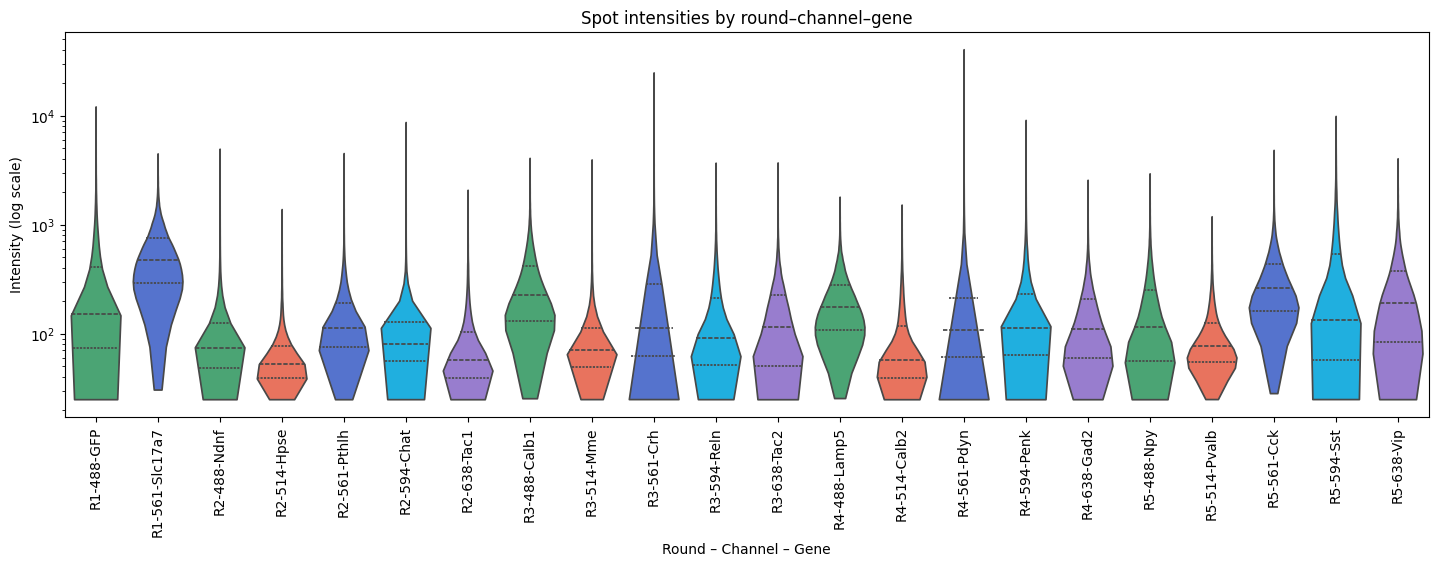

In [ ]:
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins

# "round_chan": x = Rx-NNN-Gene sorted by round then channel, colored by channel
# use saveable

filename = f"{MOUSE_ID}_intensity_violins_round_chan"
output_dir = Path("/root/capsule/results")
ax = plot_intensity_violins(subsampled_spots_df, order="round_chan",intensity_threshold=25.0,
                            save=False,filename=filename,output_dir=output_dir)


# "alpha": x = gene name sorted alphabetically
# plot_intensity_violins(spots_df_all_um, order="alpha")


       unmixed_chan round unmixed_gene  chan_488_intensity  \
0               561    R5          Cck            7.975610   
1               561    R5          Cck            8.430890   
2               561    R5          Cck           10.886180   
3               561    R5          Cck            6.097565   
4               561    R5          Cck            6.821140   
...             ...   ...          ...                 ...   
454224          638    R3         Tac2           16.430889   
454225          638    R3         Tac2           18.552851   
454226          638    R3         Tac2           72.065048   
454227          638    R3         Tac2          409.723602   
454228          638    R3         Tac2           26.747971   

        chan_514_intensity  chan_561_intensity  chan_594_intensity  \
0                24.406500          157.487793           12.349594   
1                49.528461          250.447800           16.560974   
2                79.285210          667.33331

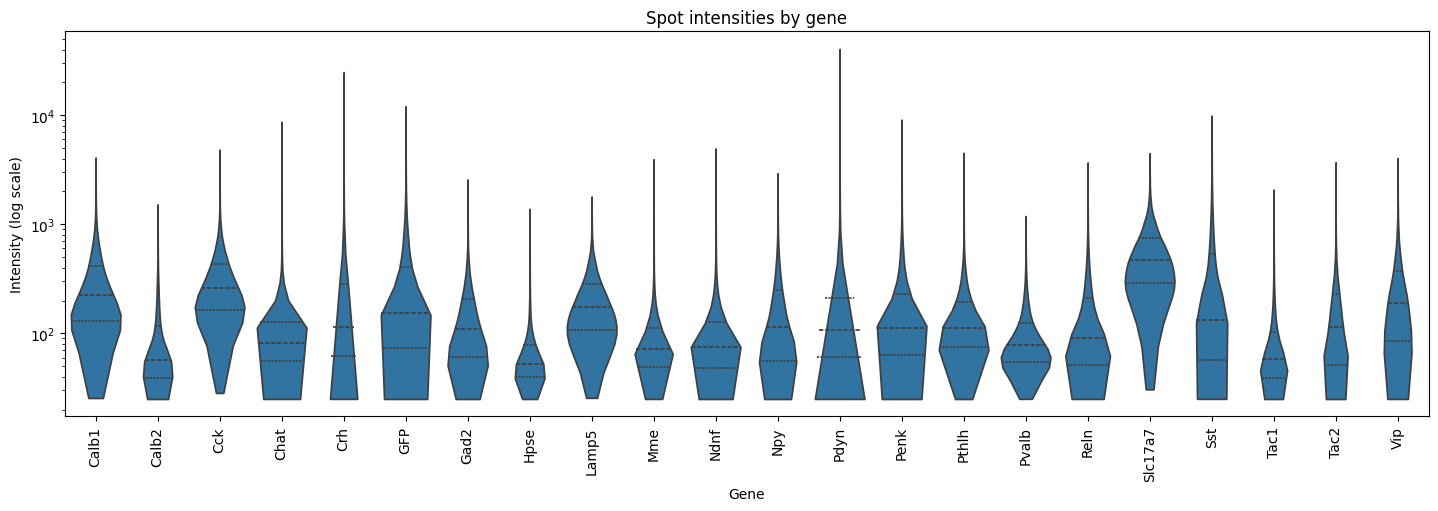

In [ ]:
filename = f"{MOUSE_ID}_intensity_violins_alpha_order"
output_dir = Path("/root/capsule/results")
ax = plot_intensity_violins(subsampled_spots_df, order="alpha",intensity_threshold=25.0,
                            save=False,filename=filename,output_dir=output_dir)

In [ ]:
ax = plot_intensity_violins(subsampled_spots_df, order="round_chan",intensity_threshold=25.0,save=True,filename=filename,output_dir=output_dir)


In [11]:
subsampled_spots_df["rd_ch_unmixed_gene"]

25066039        R5-561-Cck
25568522        R5-561-Cck
11254106      R2-561-Pthlh
727599          R1-488-GFP
22530238       R4-638-Gad2
                 ...      
4805314     R1-561-Slc17a7
18948067      R4-488-Lamp5
6812672     R1-561-Slc17a7
18264124      R4-488-Lamp5
18214346      R4-488-Lamp5
Name: rd_ch_unmixed_gene, Length: 1463674, dtype: str

Loading unmixed_spots for round R1: 782149_R1
Loading unmixed_spots for round R2: 782149_R2
Loading unmixed_spots for round R3: 782149_R3


Loading unmixed_spots for round R4: 782149_R4
Loading unmixed_spots for round R5: 782149_R5



Number of unmixed_spots: 2.927e+07
columns: ['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id', 'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity', 'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot', 'dye_line_dist_ratio', 'unmixed_chan', 'unmixed_gene', 'mixed_gene', 'chan_514_intensity', 'chan_638_intensity', 'rd_ch_unmixed_gene']
       unmixed_chan round rd_ch_unmixed_gene  chan_488_intensity  \
0               561    R5         R5-561-Cck           11.024390   
1               561    R5         R5-561-Cck           11.390240   
2               561    R5         R5-561-Cck            7.658540   
3               561    R5         R5-561-Cck           22.520325   
4               561    R5         R5-56

/src/aind-hcr-qc/src/aind_hcr_qc/utils/utils.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  


<Axes: title={'center': 'Spot intensities by round–channel–gene'}, xlabel='Round – Channel – Gene', ylabel='Intensity (log scale)'>

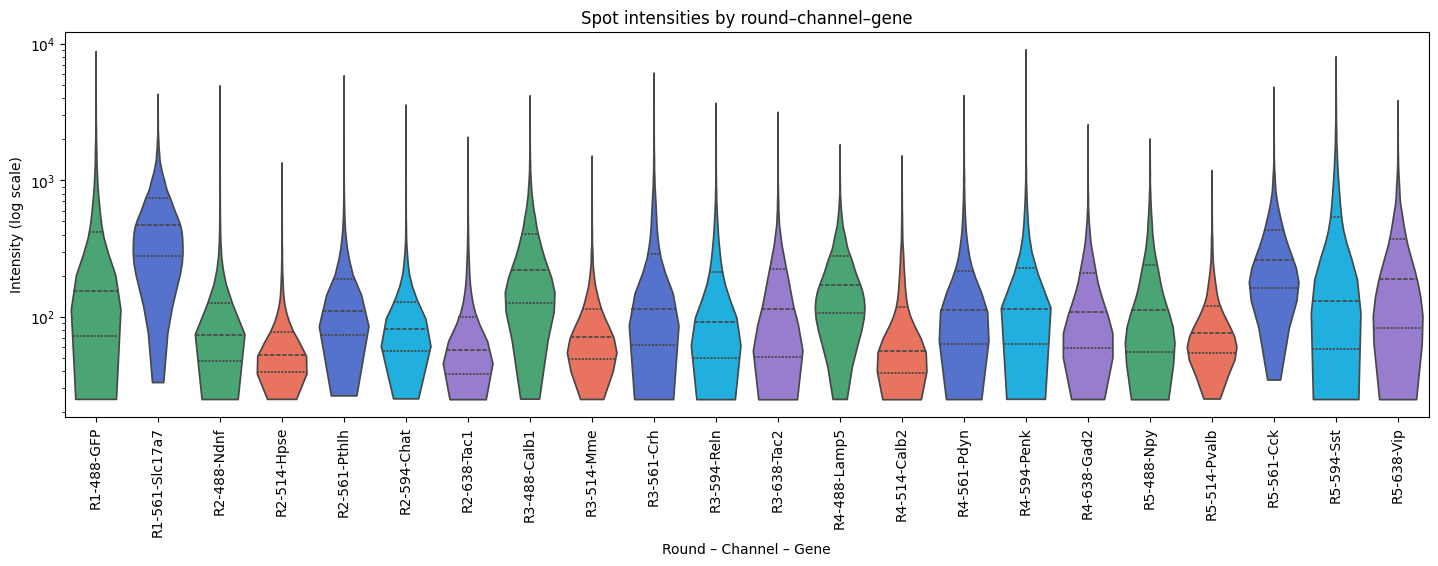

In [15]:

# Reproduce: add column fresh and pass directly to plot
_df = pw_ds.load_all_rounds_spots_mp(table_type='unmixed_spots', remove_fg_bg_cols=False)
_df['rd_ch_unmixed_gene'] = (
    _df["round"] + "-" +
    _df["unmixed_chan"] + "-" +
    _df["unmixed_gene"]
)
print("columns:", _df.columns.tolist())
plot_intensity_violins(_df.sample(frac=0.05, random_state=42), order="round_chan", intensity_threshold=25.0)


## Download plot from s3

Downloaded s3://aind-scratch-data/ctl/hcr/qc/782149/intensity_violins_round_chan.png → /tmp/qc_782149_intensity_violins_round_chan.png


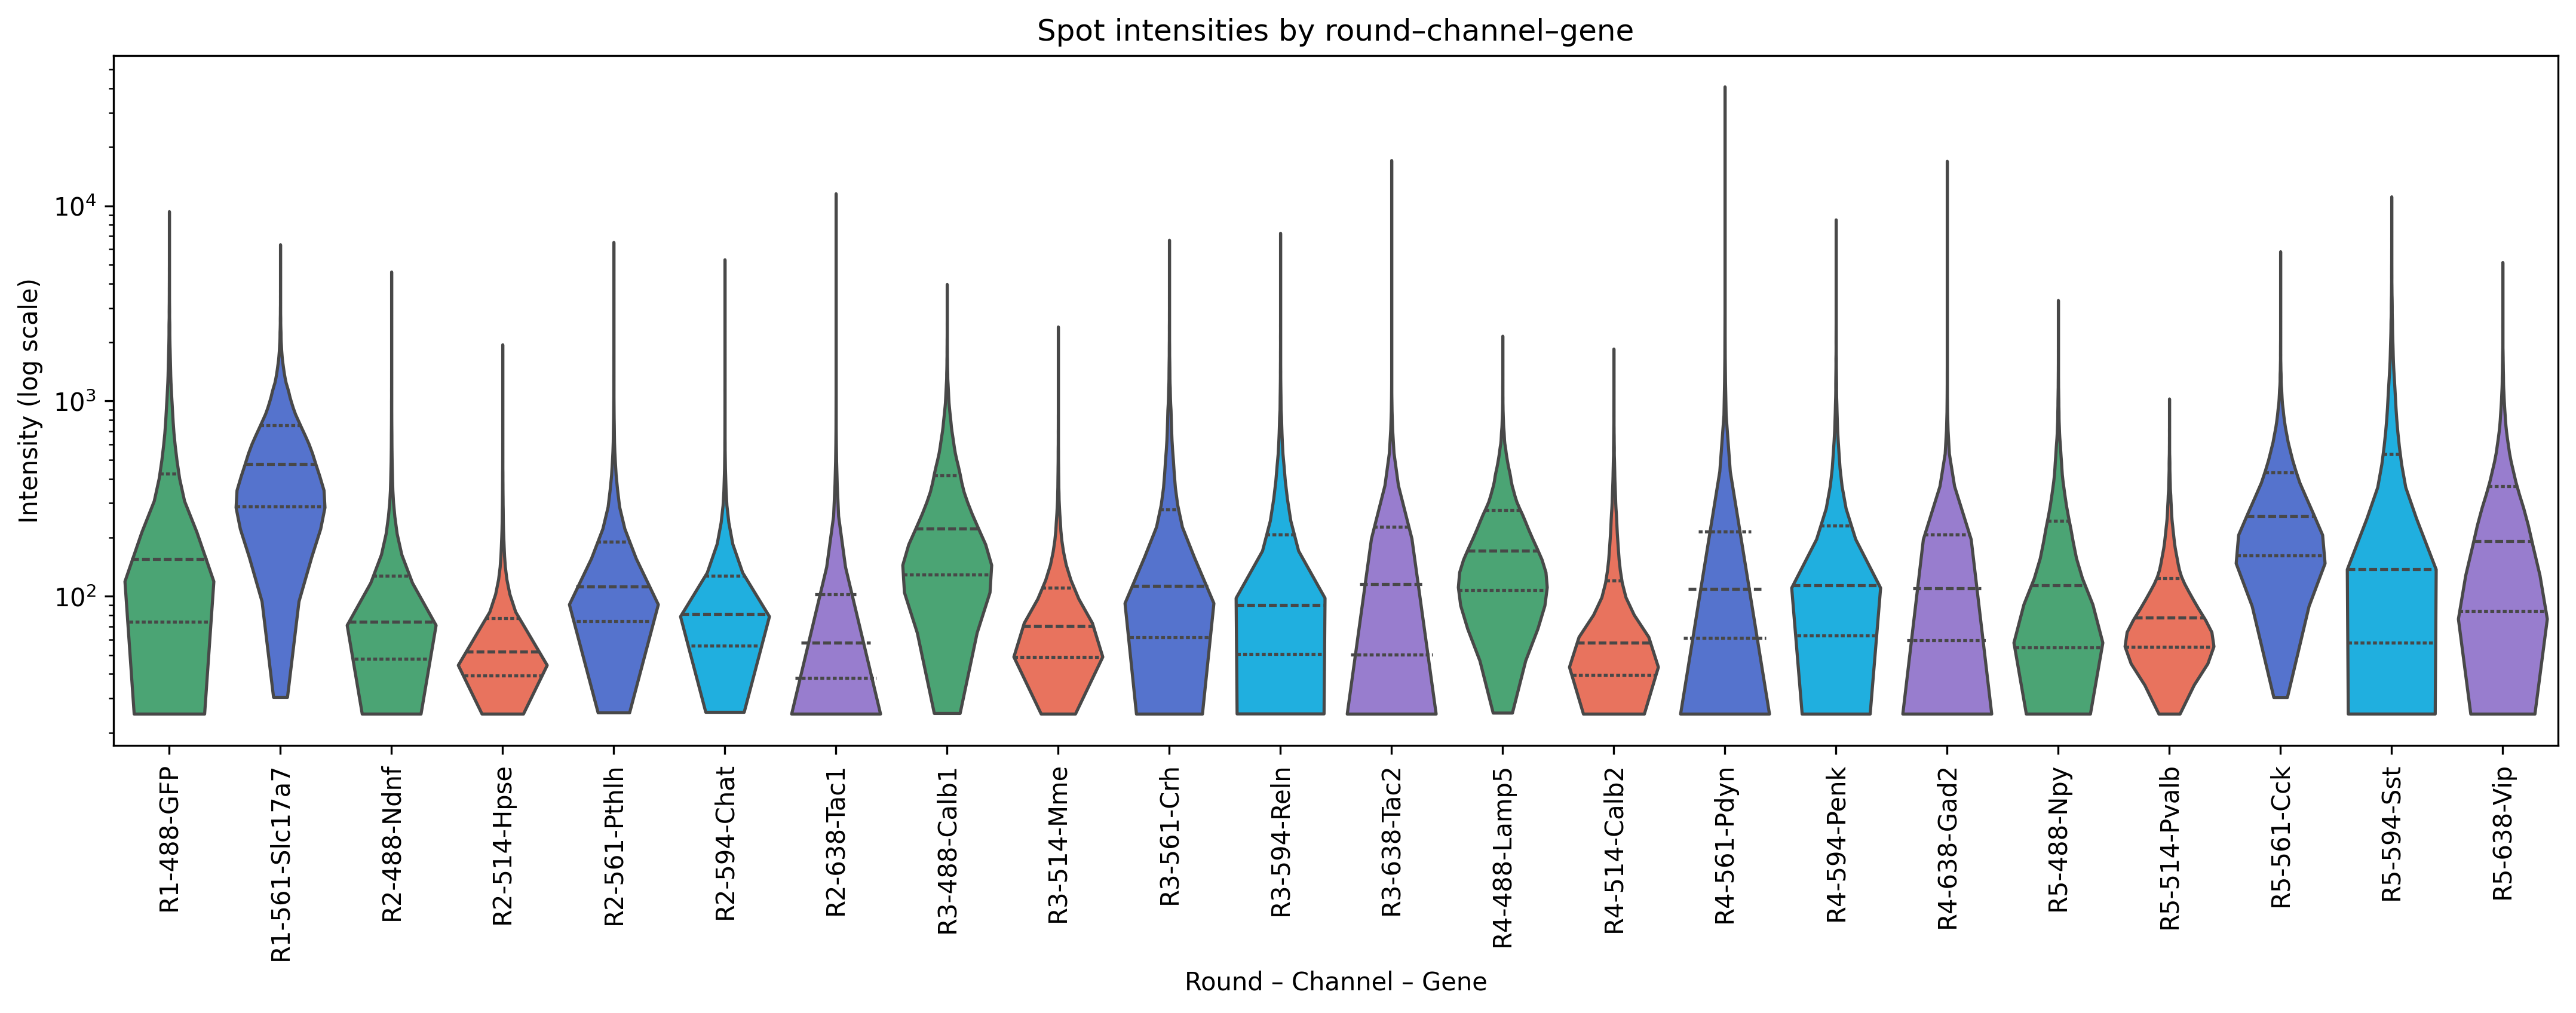

PosixPath('/tmp/qc_782149_intensity_violins_round_chan.png')

In [1]:
from aind_hcr_qc.utils.s3_qc import download_plot, QC_S3_BUCKET
download_plot(QC_S3_BUCKET, "782149", "intensity_violins_round_chan", display=True)

# Taxonomy

In [10]:
cell_info = pw_ds.get_cell_info()
cell_type_df = pw_ds.load_taxonomy_cell_types()
cells = cell_info.merge(
    cell_type_df.reset_index(),   # brings cell_id back as a column
    on="cell_id",
    how="left",
    validate="1:1",               # loud error if join assumptions are violated
)

cells.subclass_name.value_counts()

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:458: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R1


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:458: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R2


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:458: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


...

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:458: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R4


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:458: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Loading mixed cxg for round R5


subclass_name
007 L2/3 IT CTX Glut         13387
006 L4/5 IT CTX Glut          3848
330 VLMC NN                   1229
018 L2 IT PPP-APr Glut        1016
046 Vip Gaba                   818
001 CLA-EPd-CTX Car3 Glut      745
049 Lamp5 Gaba                 695
052 Pvalb Gaba                 572
053 Sst Gaba                   338
338 Lymphoid NN                317
015 ENTmv-PA-COAp Glut         283
036 HPF CR Glut                281
022 L5 ET CTX Glut             270
051 Pvalb chandelier Gaba      254
329 ABC NN                     235
336 Monocytes NN               219
337 DC NN                      215
047 Sncg Gaba                  167
333 Endo NN                    136
332 SMC NN                     126
002 IT EP-CLA Glut              88
327 Oligo NN                    86
021 L4 RSP-ACA Glut             70
050 Lamp5 Lhx6 Gaba             61
311 CBX MLI Megf11 Gaba         55
032 L5 NP CTX Glut              47
056 Sst Chodl Gaba              45
319 Astro-TE NN                 36
331 Pe

## unmixed spots

In [3]:
unmixed_all

NameError: name 'unmixed_all' is not defined

# centroids

In [18]:
def compute_cell_centroids(spots_df, cell_id_col="cell_id"):
    """
    Compute mean x, y, z centroid for each cell from a spots DataFrame.

    Averages across all spots belonging to each cell regardless of channel,
    round, or assignment status — giving a spatial centroid estimate per cell.

    Parameters
    ----------
    spots_df : pd.DataFrame
        Spots table with at least columns: cell_id, x, y, z.
    cell_id_col : str
        Column name identifying the cell each spot belongs to.

    Returns
    -------
    pd.DataFrame
        One row per cell with columns: cell_id, x_mean, y_mean, z_mean, n_spots.
    """
    return (
        spots_df
        .groupby(cell_id_col)[["x", "y", "z"]]
        .agg(
            x_mean=("x", "mean"),
            y_mean=("y", "mean"),
            z_mean=("z", "mean"),
            n_spots=("x", "count"),
        )
        .reset_index()
    )


def get_cell_centroid(spots_df, cell_id, cell_id_col="cell_id"):
    """
    Return the x, y, z centroid for a single cell as a dict.

    Parameters
    ----------
    spots_df : pd.DataFrame
        Spots table with at least columns: cell_id, x, y, z.
    cell_id : int or str
        The cell to compute the centroid for.
    cell_id_col : str
        Column name identifying the cell each spot belongs to.

    Returns
    -------
    dict with keys: cell_id, x_mean, y_mean, z_mean, n_spots.
    Raises ValueError if cell_id is not found.
    """
    sub = spots_df[spots_df[cell_id_col] == cell_id]
    if sub.empty:
        raise ValueError(f"cell_id {cell_id!r} not found in spots_df.")
    return {
        cell_id_col: cell_id,
        "x_mean":  int(round(sub["x"].mean())),
        "y_mean":  int(round(sub["y"].mean())),
        "z_mean":  int(round(sub["z"].mean())),
        "n_spots": int(len(sub)),
    }


# example
centroids = compute_cell_centroids(unmixed_all)
c_centroid = get_cell_centroid(unmixed_all, QC_CELL_ID)



(770, 4189, 7327)


In [ ]:
get_cell_centroid(unmixed_all, QC_CELL_ID)

# single cell plots

In [26]:
import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
)



PLOTTING ALL CHANNELS FOR CELL 25690 - ROUND R5
Available channels: ['405', '488', '514', '561', '594', '638']
Channel-gene mapping: {'488': 'Npy', '514': 'Pvalb', '561': 'Cck', '594': 'Sst', '638': 'Vip'}

Loading cell info and segmentation data...
Loading mixed cxg for round R5


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:458: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(


Using reference channel 405 for segmentation overlay
Extracting cell volume for cell 25690...


/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


Reference channel shape: (1, 1, 985, 9290, 9281)
Extracting cell 25690 at centroid (z, y, x) = (758, 8680, 5028)
Labels in chunk: [    0 21901 23362 24364 25173 25690 27260 30305 31004 31664 32198 34813
 36601 36644 37302]
z: 658 to 858, y: 8580 to 8780, x: 4928 to 5128
zarr shape: (1, 1, 985, 9290, 9281)
Cell centroid (z, y, x): [ 758 8680 5028]
Cell crop shape: (131, 211, 203)
Origin: (np.int64(628), np.int64(8530), np.int64(4878))
Z-planes: [53 59 65 71 78]


/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


Loaded 6 channels ['405', '488', '514', '561', '594', '638'], crop shape: (131, 211, 203)

Creating figure: 1x6 grid, figsize=(24, 5)
Plotting z-plane 65 (global z: 693)
LUTs: Ch405=[120-1814]  Ch488=[96-2747]  Ch514=[99-501]  Ch561=[108-2434]  Ch594=[95-4427]  Ch638=[88-251]

Plot completed successfully!
{'='*60}


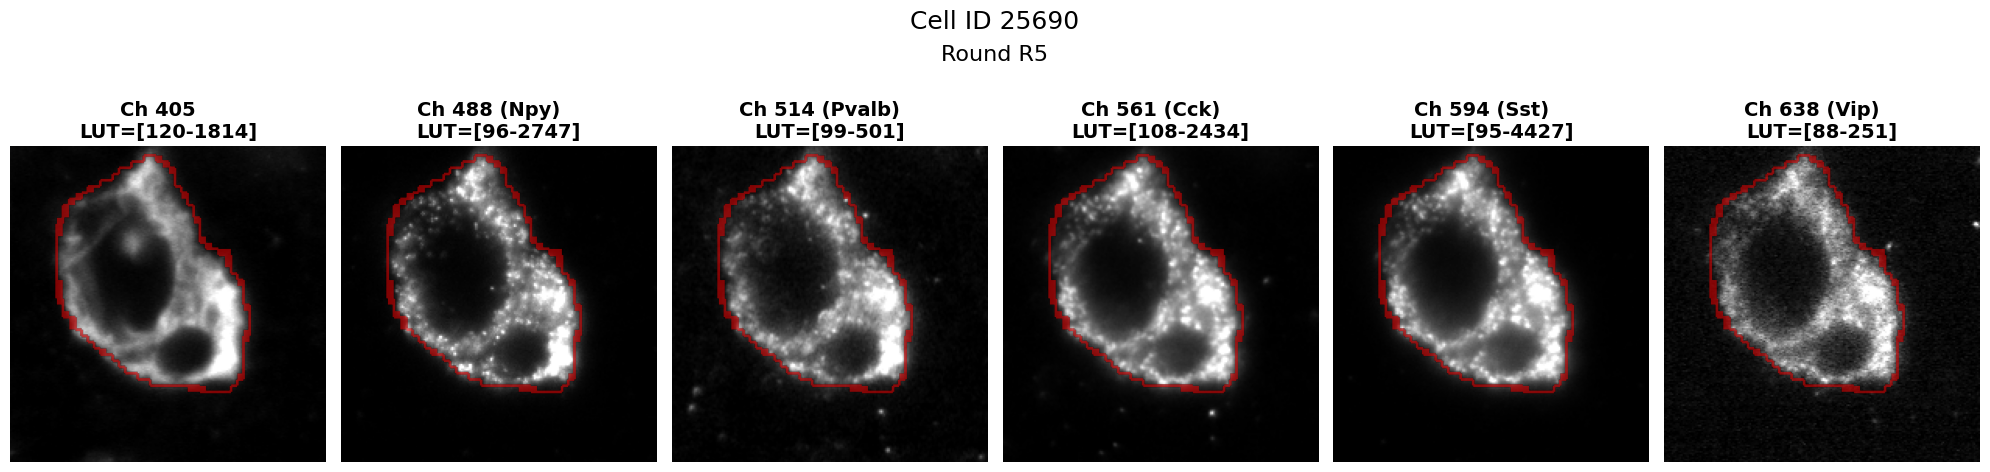

In [12]:
#rounds = ["R1", "R2", "R3", "R4", "R5",]
rounds = ["R5"]
pyramid_level = "0"
plot_cell_id = 25690

viz.plot_single_cell_expression_all_rounds(plot_cell_id, dataset, "0", rounds, verbose=True)
plt.show()

# Single-cell unmixing QC

Three complementary plots for one cell × one round to assess spectral unmixing quality:

1. **2D spot projection** — all spots from the 3D volume projected to XY, colored by channel assignment before vs after unmixing. Reassigned spots are highlighted.
2. **Cross-channel intensity profile heatmap** — for spots grouped by their assigned channel, show mean intensity in every channel. Good unmixing → near-diagonal matrix.
3. **Adjacent-channel scatter** — pairwise scatter of neighboring channel intensities, colored by assignment. Pre-unmixing shows overlap; post-unmixing spots separate toward their channel axis.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import pandas as pd

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

# ── load spots (both tables) for this cell ───────────────────────────────────
mixed_all   = pw_ds.load_all_rounds_spots_mp(table_type="mixed_spots",   remove_fg_bg_cols=True)
unmixed_all = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=True)




Loading mixed_spots for round R1: 782149_R1
Loading mixed_spots for round R2: 782149_R2
Loading mixed_spots for round R3: 782149_R3

Loading mixed_spots for round R4: 782149_R4
Loading mixed_spots for round R5: 782149_R5




Number of mixed_spots: 3.628e+07
Loading unmixed_spots for round R1: 782149_R1
Loading unmixed_spots for round R3: 782149_R3
Loading unmixed_spots for round R2: 782149_R2


Loading unmixed_spots for round R4: 782149_R4
Loading unmixed_spots for round R5: 782149_R5



Number of unmixed_spots: 2.927e+07


In [14]:
unmixed_all

,spot_id,spot_uid,spot_uid_int,chan,chan_spot_id,cell_id,round,z,y,x,...,chan_561_intensity,chan_594_intensity,over_thresh,valid_spot,dye_line_dist_ratio,unmixed_chan,unmixed_gene,mixed_gene,chan_514_intensity,chan_638_intensity
0,0,488_23,0,488,23,16,R1,69,788,573,...,27.244551,32.674789,False,False,8.674192,488,GFP,GFP,NaN,NaN
1,1,488_24,1,488,24,16,R1,67,771,611,...,32.000000,131.829895,True,False,114.436775,488,GFP,GFP,NaN,NaN
2,2,488_25,2,488,25,16,R1,67,771,622,...,67.090080,150.424698,True,False,31.791004,488,GFP,GFP,NaN,NaN
3,3,488_26,3,488,26,16,R1,67,772,583,...,47.211380,88.170731,False,False,20.737095,488,GFP,GFP,NaN,NaN
4,4,488_27,4,488,27,16,R1,67,775,569,...,171.333344,33.090080,False,False,1.856051,488,GFP,GFP,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29273468,8449611,638_370558,8449611,638,370558,39011,R5,826,6972,8884,...,158.422760,50.292679,True,False,1.775002,638,Vip,Vip,25.634150,58.756100
29273469,8449612,638_370559,8449612,638,370559,39011,R5,833,6981,8844,...,415.365845,115.934952,True,False,1.885957,638,Vip,Vip,55.268299,160.447159
29273470,8449613,638_370862,8449613,638,370862,39090,R5,843,7213,8892,...,139.552841,51.195129,True,False,1.343588,638,Vip,Vip,20.154470,72.821136
29273471,8449614,638_370863,8449614,638,370863,39090,R5,848,7180,8797,...,131.399673,29.715450,True,False,2.354146,638,Vip,Vip,27.821787,38.430901


In [32]:
# ── config ────────────────────────────────────────────────────────────────────
QC_CELL_ID  = 33839 #30548 #33839#25690   # reuse the cell shown in the image panel above
QC_ROUND    = "R5"

# filter to the cell and round we care about (unmixed table has both chan + unmixed_chan)
u_cell = unmixed_all[(unmixed_all["cell_id"] == QC_CELL_ID) & (unmixed_all["round"] == QC_ROUND)].copy()
m_cell = mixed_all[  (mixed_all["cell_id"]   == QC_CELL_ID) & (mixed_all["round"]   == QC_ROUND)].copy()

# reassignment: chan changed in the unmixed table
u_cell["reassigned"] = u_cell["chan"] != u_cell["unmixed_chan"]

# removed: spots present in the mixed table but absent from the unmixed table
survived_uids = set(u_cell["spot_uid"])
m_cell["removed"] = ~m_cell["spot_uid"].isin(survived_uids)

# per-channel intensity columns present in this dataset
INTENSITY_COLS = [c for c in u_cell.columns if c.startswith("chan_") and c.endswith("_intensity")]
INTENSITY_CHANS = [c.replace("chan_", "").replace("_intensity", "") for c in INTENSITY_COLS]


### Plot 1 — 2D XY spot projection (before vs after unmixing)

Project all 3-D spots onto XY. Left panel colored by detected channel, right panel by reassigned channel. Re-assigned spots are shown with a black ring so you can immediately see which spots moved and where.



1-NN cross-channel distance summary  ((x×y×z, x=0.24  y=0.24  z=1.0 µm/px)):
     Direction      n    median      mean       std       min       max
     488 → 514    145     7.485     8.187     3.603     1.292    16.648
     514 → 488      5     2.833     2.626     0.825     1.292     3.579
     514 → 561      5     2.332     2.834     1.697     1.200     6.085
     561 → 514     99     8.334     8.504     3.620     1.200    15.219
     561 → 594     99     1.200     1.332     0.406     1.018     3.124
     594 → 561    656     2.683     2.955     1.401     1.018     7.869
     594 → 638    656     9.864     9.881     4.325     1.028    20.931
     638 → 594      6     1.321     1.268     0.166     1.028     1.467


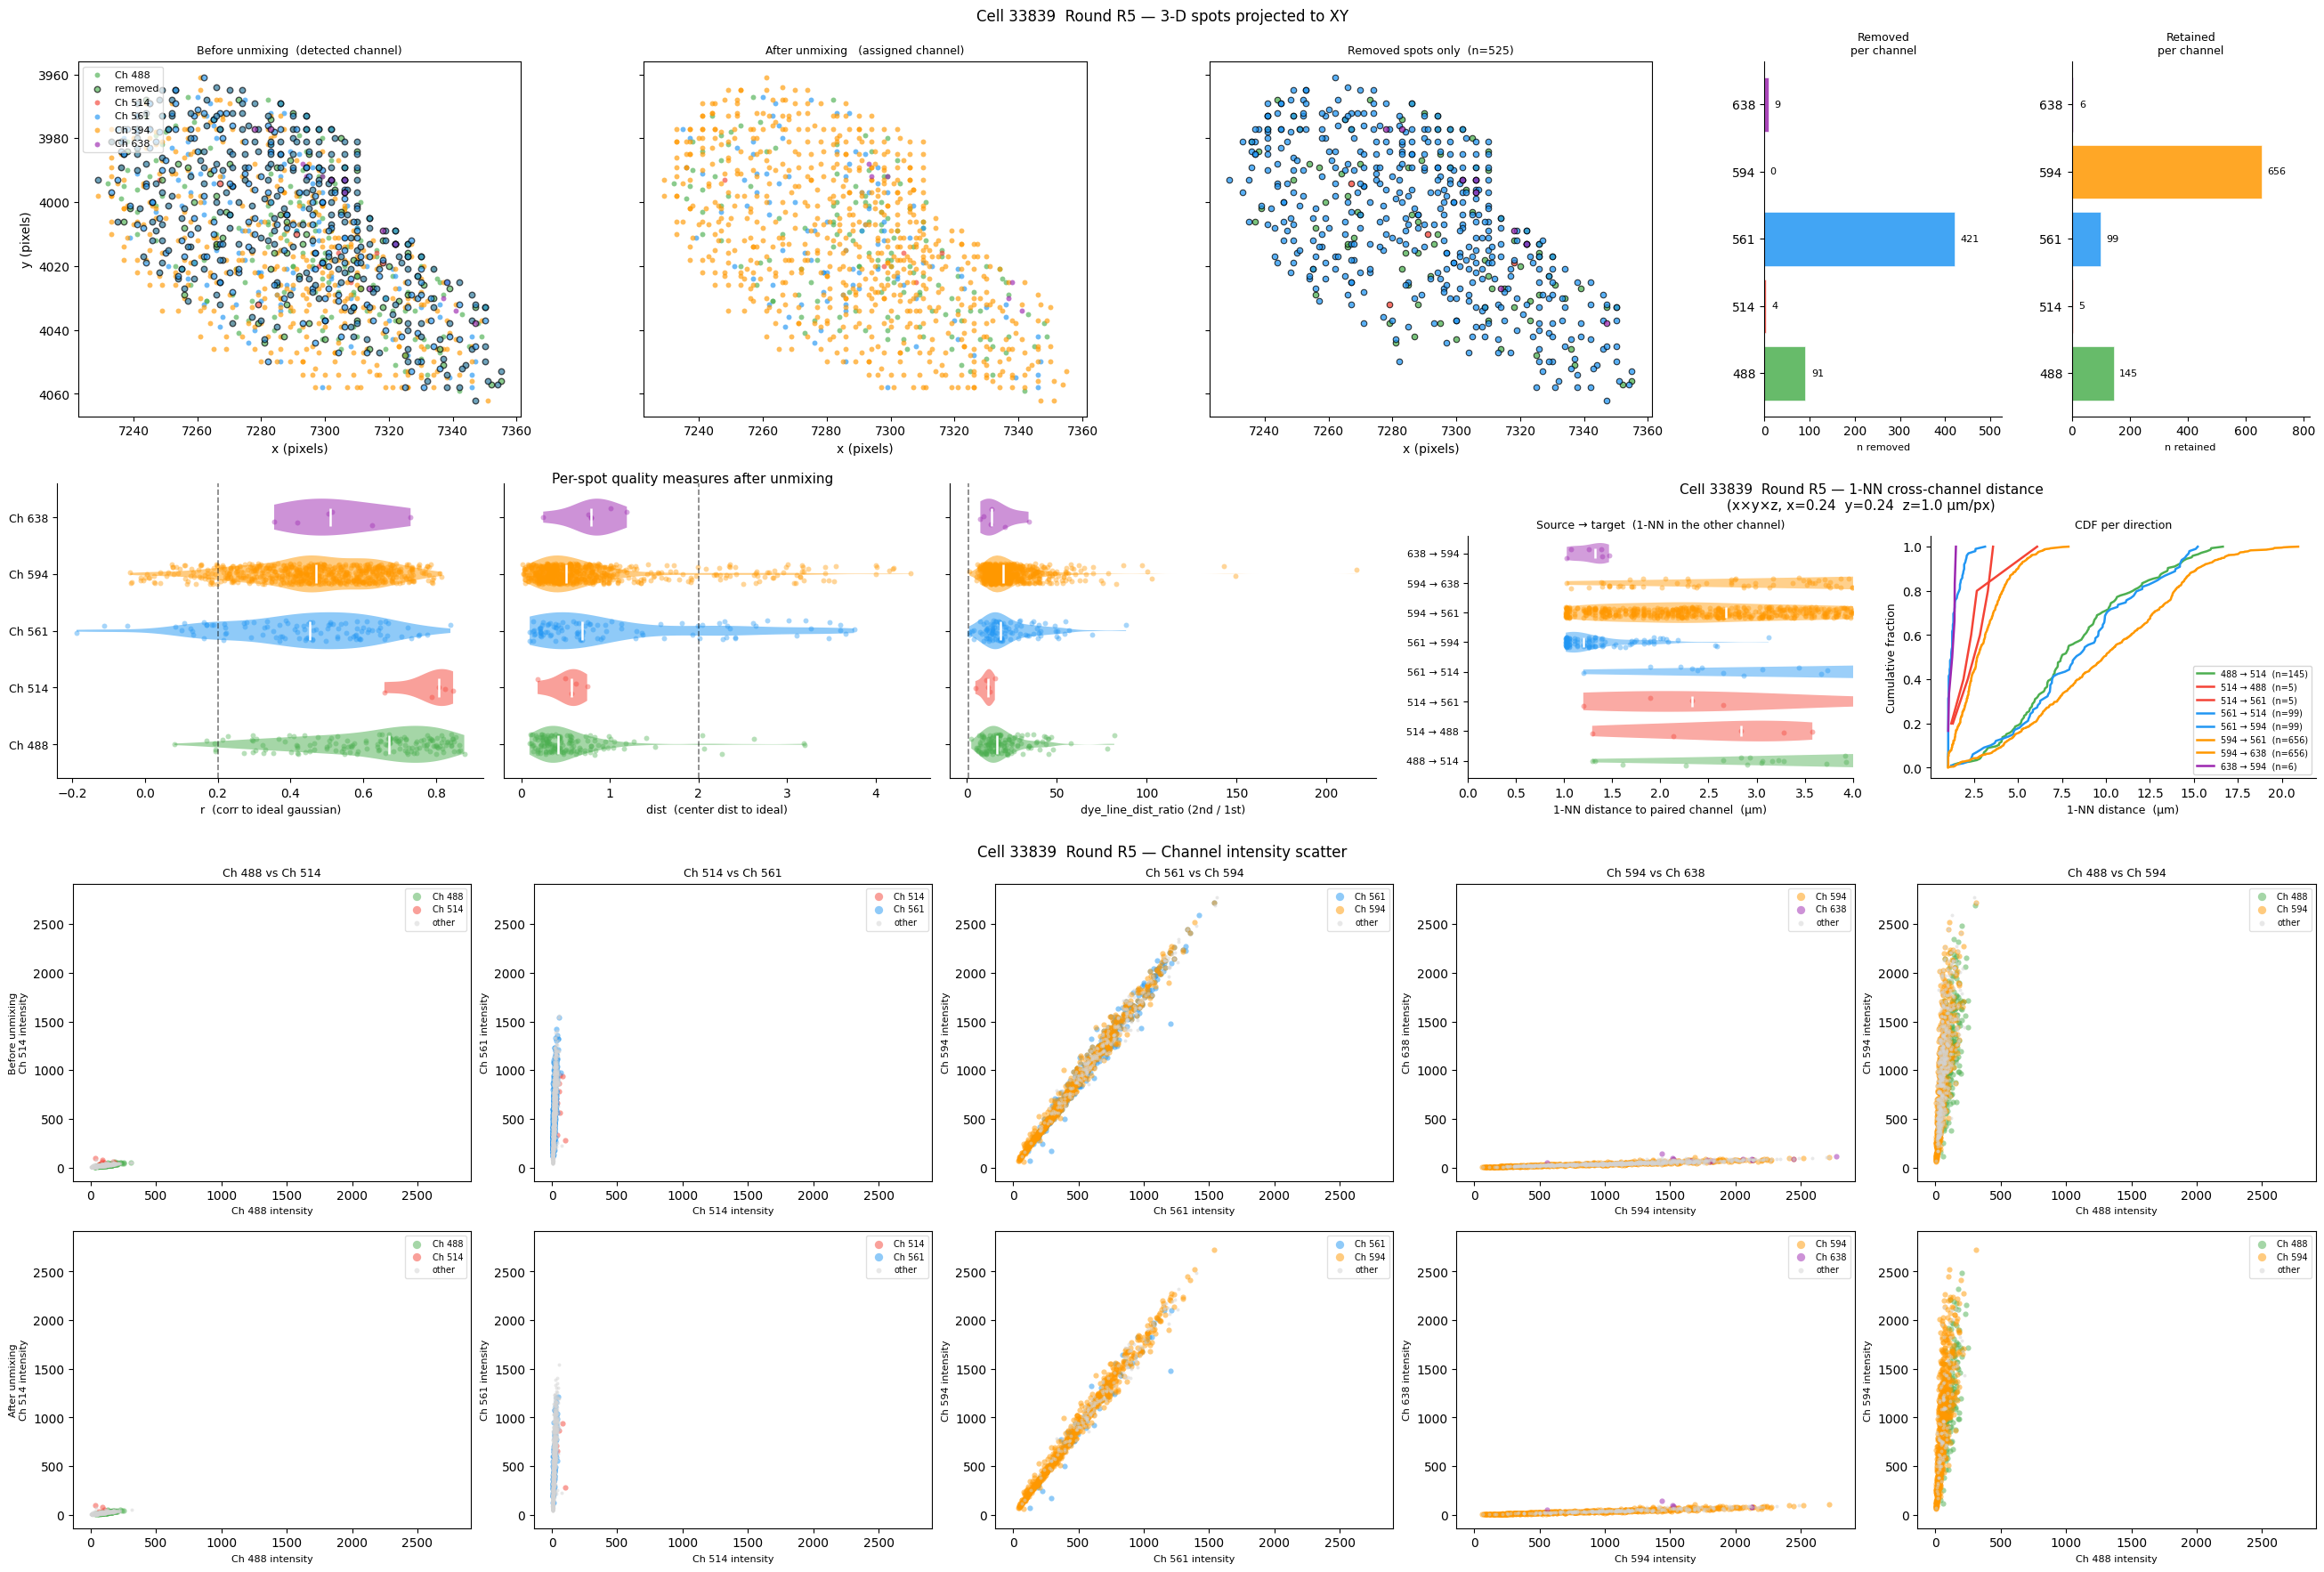

In [33]:
plot_cell_qc(m_cell, u_cell, QC_CELL_ID, QC_ROUND,
             thresholds={"r": 0.2, "dist": 2, "dye_line_dist_ratio": 1},
             spots_df=u_cell,
             voxel_size={"z": 1.0, "y": 0.24, "x": 0.24},
             scatter_pairs=[("488", "514"), ("514", "561"), ("561", "594"), ("594", "638"), ("488", "594")])


1-NN cross-channel distance summary  ((x×y×z, x=0.24  y=0.24  z=1.0 µm/px)):
     Direction      n    median      mean       std       min       max
     488 → 514      5     6.193     5.387     1.613     3.311     7.350
     514 → 488     25     9.802     9.254     3.348     3.311    16.104
     514 → 561     25     1.056     1.424     0.620     1.028     3.447
     561 → 514    320     4.175     4.290     1.916     1.028     9.575
     561 → 594    320     7.464     8.066     4.043     1.056    17.946
     594 → 561      9     1.467     1.795     0.788     1.056     3.440
     594 → 638      9     5.944     6.772     2.356     4.114    11.795
     638 → 594      3     4.724     6.877     3.486     4.114    11.795


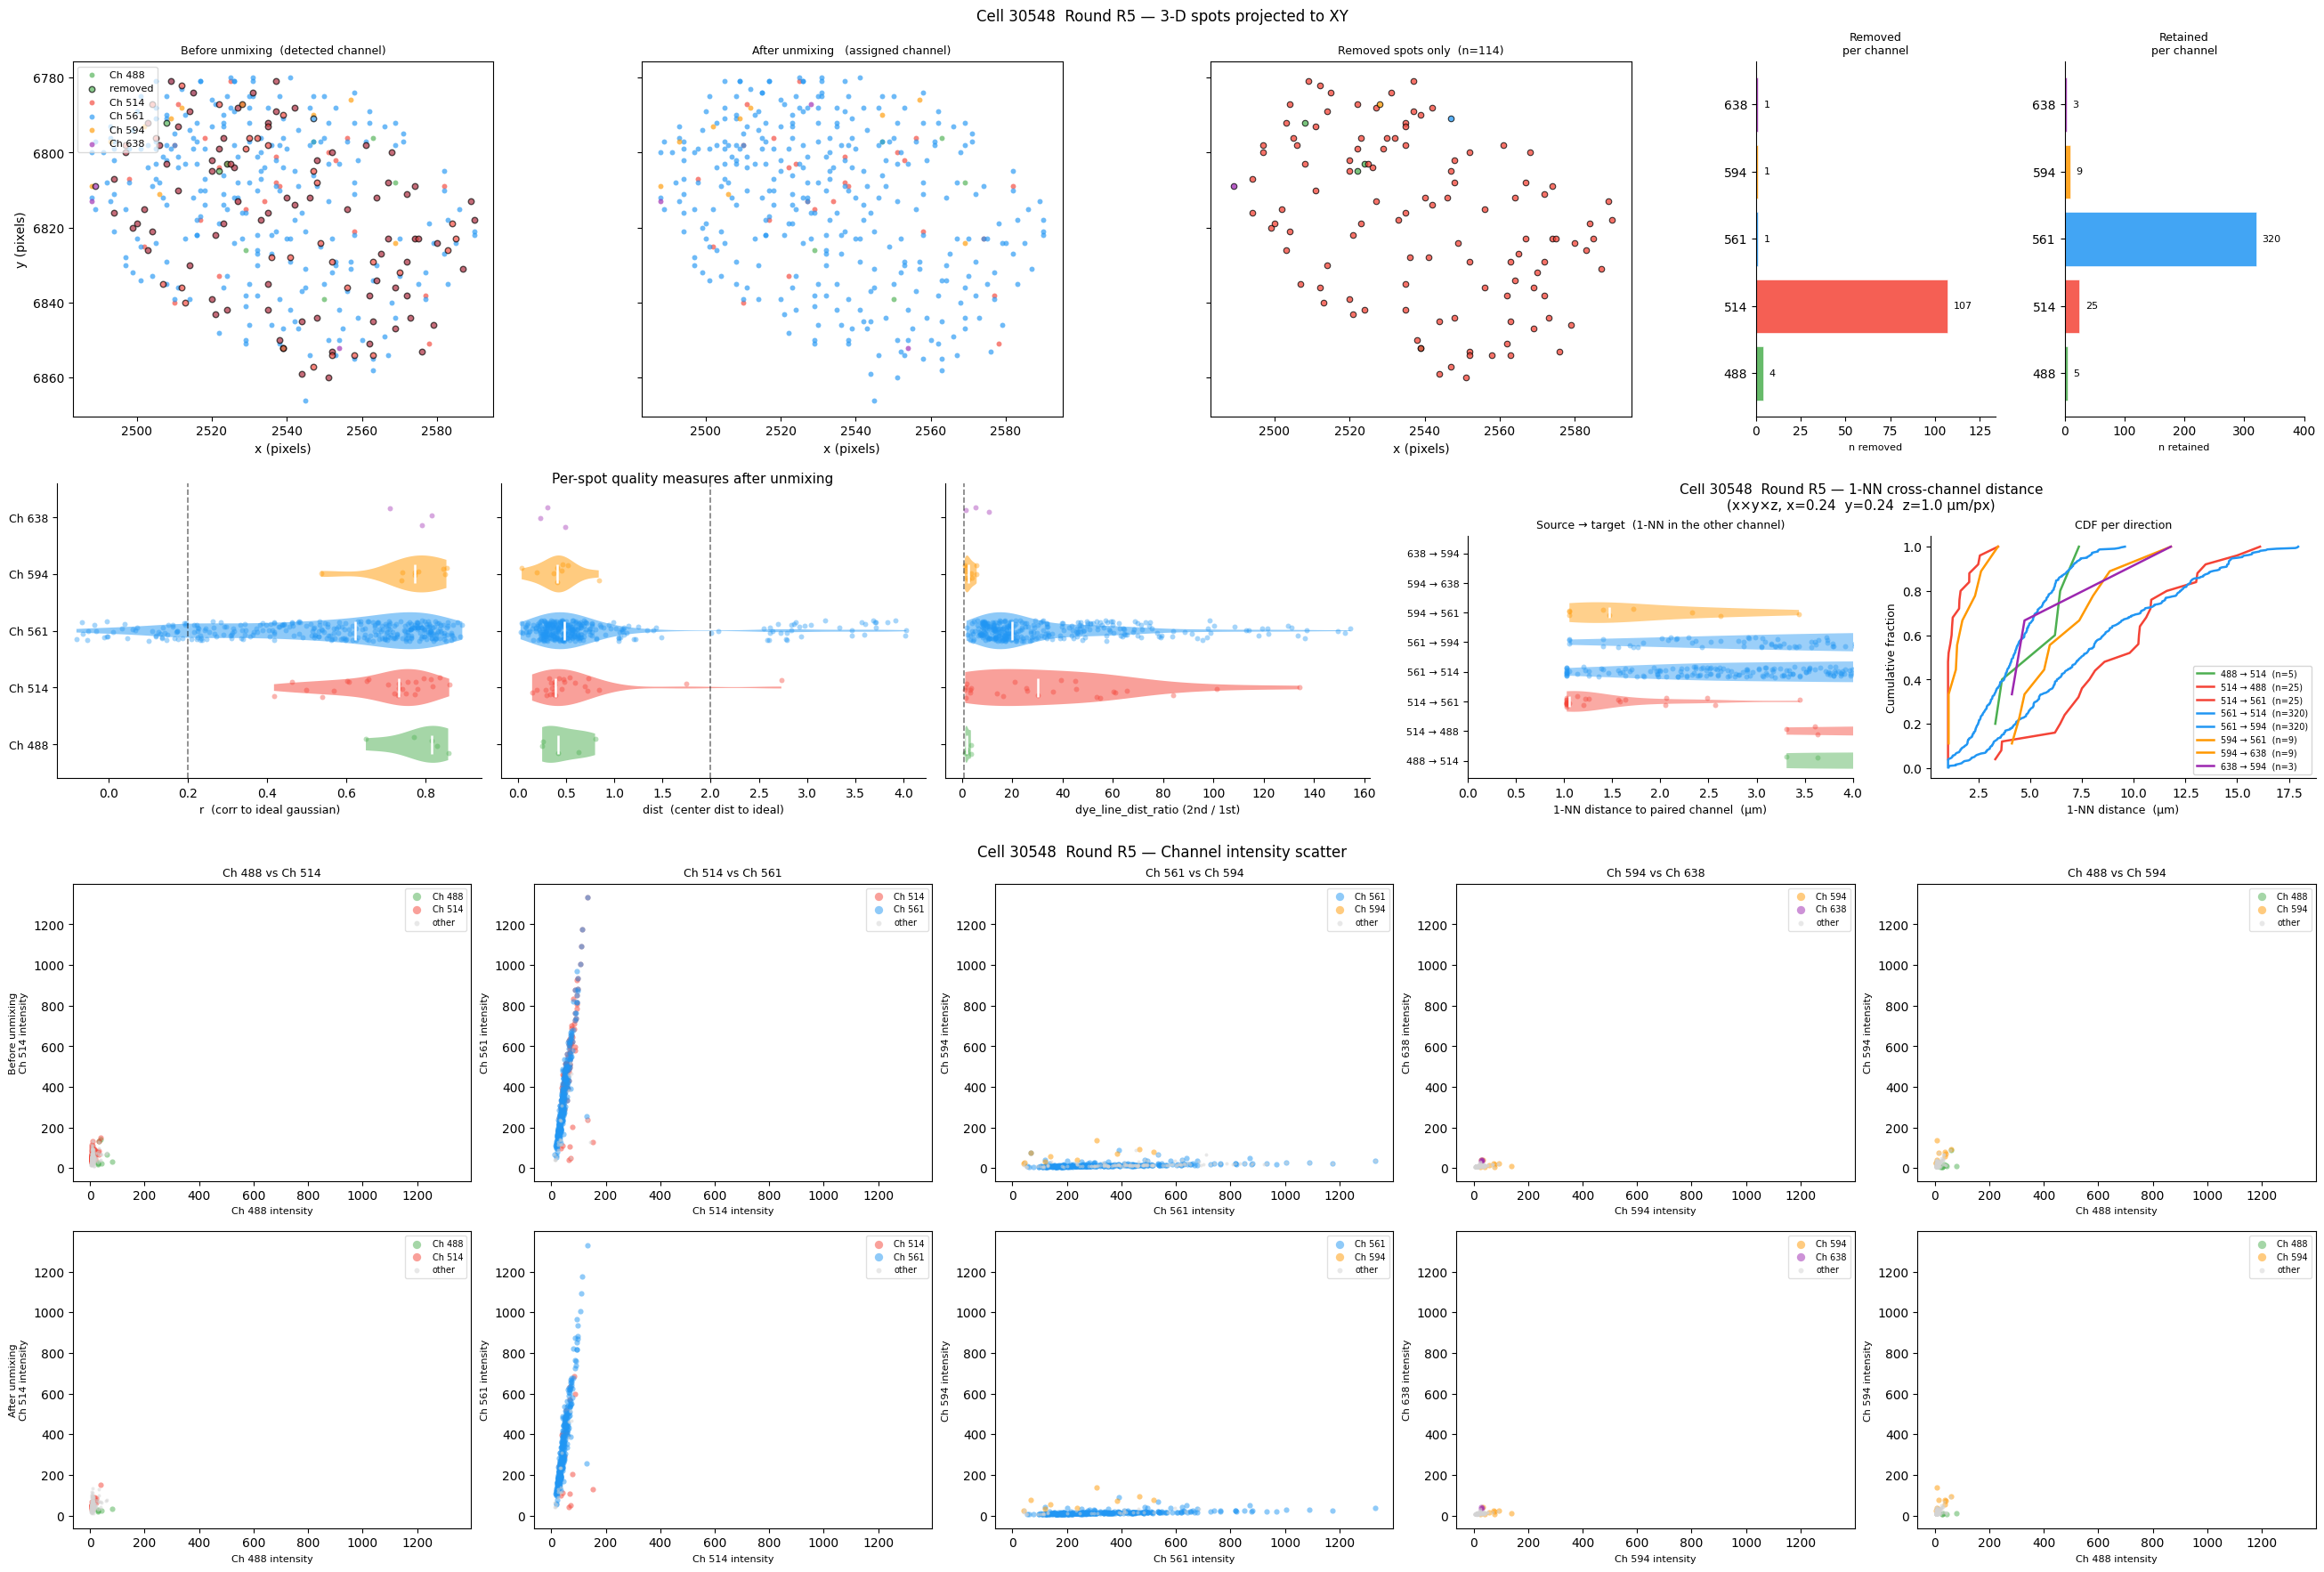

In [31]:
plot_cell_qc(m_cell, u_cell, QC_CELL_ID, QC_ROUND,
             thresholds={"r": 0.2, "dist": 2, "dye_line_dist_ratio": 1},
             spots_df=u_cell,
             voxel_size={"z": 1.0, "y": 0.24, "x": 0.24},
             scatter_pairs=[("488", "514"), ("514", "561"), ("561", "594"), ("594", "638"), ("488", "594")])


In [58]:
pw_ds.rounds[QC_ROUND].load_ratios_matrix()

,1,2,3,4
0,,,,
99.0,26.0,1.0,6.0,1.0
16.0,100.0,11.0,1.0,4.0
7.0,14.0,100.0,52.0,29.0
5.0,8.0,3.0,100.0,57.0
1.0,3.0,1.0,3.0,100.0


Raw ratios_df shape (after index_col=0): (5, 4)
  index: [99.0, 16.0, 7.0, 5.0, 1.0]
  columns: ['1', '2', '3', '4']
Recovered full matrix shape: (5, 5)
[[ 99.  26.   1.   6.   1.]
 [ 16. 100.  11.   1.   4.]
 [  7.  14. 100.  52.  29.]
 [  5.   8.   3. 100.  57.]
 [  1.   3.   1.   3. 100.]]

638-assigned spots in cell 33839, round R5: 6
Distance columns: ['d_488', 'd_514', 'd_561', 'd_594', 'd_638']

d_assignment_ratio  (d_638 / d_min_other):
count     6.000
mean     16.435
std       9.928
min       7.431
25%      10.065
50%      13.435
75%      19.214
max      34.230
Name: d_assignment_ratio, dtype: float64
ratio > 1 (misassigned): 6 / 6


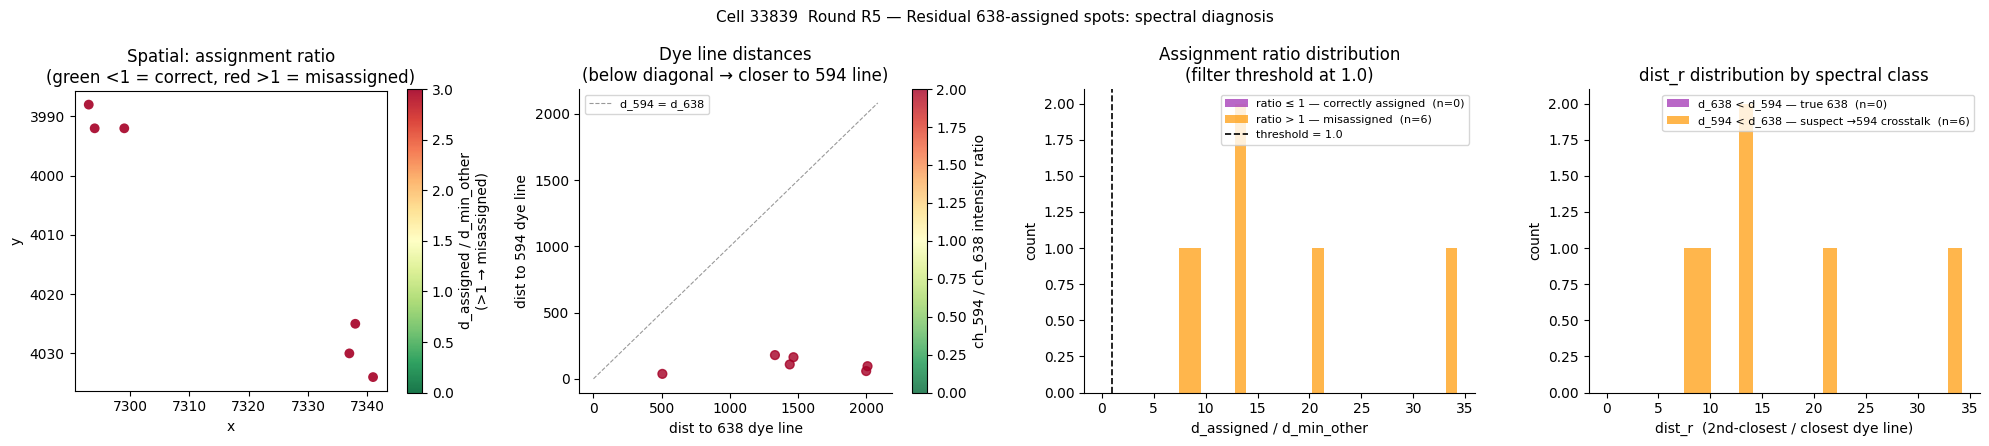


Misassigned (d_assignment_ratio > 1): 6 / 6
  median d_assignment_ratio : 13.43
  median d_assigned (d_638) : 1451.65
  median d_min_other        : 101.76


In [19]:

# ── CPU distance diagnostic: residual 638-assigned spots ─────────────────────
def compute_dye_line_distances_numpy(spots_df, ratios_df, chan_order=CHAN_ORDER):
    """
    Numpy equivalent of PairwiseUnmixer.calculate_distances.

    load_ratios_matrix() reads the CSV with index_col=0, so the first data
    column becomes the DataFrame index — leaving an apparent (n_ch, n_ch-1)
    shape. We recover the full (n_ch × n_ch) matrix by prepending the index
    back as the first column before computing distances.

    Columns of the ratios matrix = dye lines, one per channel (488..638).
    Returns d_{ch} columns (dist to each dye line) + dist_r_np.
    """
    intensity_cols = [f"chan_{ch}_intensity" for ch in chan_order
                      if f"chan_{ch}_intensity" in spots_df.columns]
    chans_used = [c.replace("chan_", "").replace("_intensity", "") for c in intensity_cols]

    if not intensity_cols:
        available = [c for c in spots_df.columns if "intensity" in c]
        raise ValueError(f"No intensity columns matched. Available: {available}")

    data = spots_df[intensity_cols].values.astype(np.float64)  # (n_spots, n_ch)

    # Recover full n_ch × n_ch matrix: prepend the index as the first column
    ratios_raw = np.hstack([
        np.array(ratios_df.index.values, dtype=float).reshape(-1, 1),
        ratios_df.values.astype(float),
    ])  # (n_ch, n_ch)
    n_ch_r = ratios_raw.shape[0]
    ratios_full = pd.DataFrame(
        ratios_raw,
        index=chan_order[:n_ch_r],
        columns=chan_order[:n_ch_r],
    )

    # Rows = channel dimensions; select only rows matching intensity data
    ratios = ratios_full.loc[chans_used].values.astype(np.float64)  # (n_ch_used, n_lines)
    ratios_norm = ratios / np.linalg.norm(ratios, axis=0)            # column-normalise

    projections = data @ ratios_norm                                          # (n_spots, n_lines)
    fit = projections[:, :, np.newaxis] * ratios_norm.T[np.newaxis]          # (n_spots, n_lines, n_ch)
    distances = np.linalg.norm(data[:, np.newaxis, :] - fit, axis=2)         # (n_spots, n_lines)

    # Each column i of distances = perpendicular dist to the i-th dye line
    dye_line_labels = chan_order[:ratios_raw.shape[1]]  # same order as ratios columns
    dist_df = pd.DataFrame(distances,
                           columns=[f"d_{ch}" for ch in dye_line_labels],
                           index=spots_df.index)
    sorted_d = np.sort(distances, axis=1)
    dist_df["dist_r_np"] = sorted_d[:, 1] / np.maximum(sorted_d[:, 0], 1e-10)
    return dist_df


# ── load ratios for QC_ROUND ──────────────────────────────────────────────────
ratios_df = pw_ds.rounds[QC_ROUND].load_ratios_matrix()

print(f"Raw ratios_df shape (after index_col=0): {ratios_df.shape}")
print(f"  index: {ratios_df.index.tolist()}")
print(f"  columns: {ratios_df.columns.tolist()}")
# Recover full matrix for inspection
_full = np.hstack([np.array(ratios_df.index.values, dtype=float).reshape(-1,1), ratios_df.values.astype(float)])
_full_df = pd.DataFrame(_full, columns=["index"] + ratios_df.columns.tolist())
print(f"Recovered full matrix shape: {_full.shape}")
print(_full)

# ── filter to 638-assigned spots ─────────────────────────────────────────────
u_638 = u_cell[u_cell["unmixed_chan"] == "638"].copy().reset_index(drop=True)
print(f"\n638-assigned spots in cell {QC_CELL_ID}, round {QC_ROUND}: {len(u_638)}")

dist_df = compute_dye_line_distances_numpy(u_638, ratios_df, chan_order=CHAN_ORDER)
u_638 = pd.concat([u_638, dist_df], axis=1)
print("Distance columns:", [c for c in u_638.columns if c.startswith("d_")])

# ── assignment quality ratio: d_assigned / d_min_other ───────────────────────
# For spots assigned to 638: how far is the spot from its assigned dye line
# relative to the closest *other* dye line?
# ratio < 1 → correctly assigned (638 truly is the nearest dye line)
# ratio > 1 → misassigned (some other dye line is closer; threshold = 1.0)
assigned_chan = "638"
other_d_cols = [f"d_{ch}" for ch in CHAN_ORDER if ch != assigned_chan and f"d_{ch}" in u_638.columns]
d_assigned   = u_638[f"d_{assigned_chan}"]
d_min_other  = u_638[other_d_cols].min(axis=1)
u_638["d_assignment_ratio"] = d_assigned / d_min_other.replace(0, np.nan)

print(f"\nd_assignment_ratio  (d_638 / d_min_other):")
print(u_638["d_assignment_ratio"].describe().round(3))
n_misassigned = (u_638["d_assignment_ratio"] > 1).sum()
print(f"ratio > 1 (misassigned): {n_misassigned} / {len(u_638)}")

# ── plot ──────────────────────────────────────────────────────────────────────
d_594_col = "d_594"
d_638_col = "d_638"

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
fig.suptitle(
    f"Cell {QC_CELL_ID}  Round {QC_ROUND} — Residual 638-assigned spots: spectral diagnosis",
    fontsize=11)

# Panel 0: spatial XY coloured by d_assignment_ratio
sc0 = axes[0].scatter(u_638["x"], u_638["y"],
                      c=u_638["d_assignment_ratio"], cmap="RdYlGn_r", vmin=0, vmax=3,
                      s=50, alpha=0.9, linewidths=0)
fig.colorbar(sc0, ax=axes[0], label="d_assigned / d_min_other\n(>1 → misassigned)")
axes[0].set_title("Spatial: assignment ratio\n(green <1 = correct, red >1 = misassigned)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_aspect("equal"); axes[0].invert_yaxis()

# Panel 1: d_638 vs d_594, coloured by intensity ratio
int_ratio = (u_638["chan_594_intensity"] / u_638["chan_638_intensity"].replace(0, np.nan)
             if "chan_594_intensity" in u_638.columns else None)
sc1 = axes[1].scatter(u_638[d_638_col], u_638[d_594_col],
                      c=int_ratio, cmap="RdYlGn_r", vmin=0, vmax=2,
                      s=40, alpha=0.8)
if int_ratio is not None:
    fig.colorbar(sc1, ax=axes[1], label="ch_594 / ch_638 intensity ratio")
lim = max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])
axes[1].plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.4, label="d_594 = d_638")
axes[1].legend(fontsize=8)
axes[1].set_xlabel("dist to 638 dye line")
axes[1].set_ylabel("dist to 594 dye line")
axes[1].set_title("Dye line distances\n(below diagonal → closer to 594 line)")
axes[1].spines[["top", "right"]].set_visible(False)

# Panel 2: d_assignment_ratio histogram — the filter metric
misassigned = u_638["d_assignment_ratio"] > 1
axes[2].hist(u_638.loc[~misassigned, "d_assignment_ratio"], bins=25, alpha=0.7,
             color=CHAN_COLORS.get("638", "#9C27B0"),
             label=f"ratio ≤ 1 — correctly assigned  (n={int((~misassigned).sum())})")
axes[2].hist(u_638.loc[misassigned, "d_assignment_ratio"], bins=25, alpha=0.7,
             color=CHAN_COLORS.get("594", "#FF9800"),
             label=f"ratio > 1 — misassigned  (n={int(misassigned.sum())})")
axes[2].axvline(1.0, color="black", lw=1.2, ls="--", label="threshold = 1.0")
axes[2].set_xlabel("d_assigned / d_min_other")
axes[2].set_ylabel("count")
axes[2].set_title("Assignment ratio distribution\n(filter threshold at 1.0)")
axes[2].legend(fontsize=8)
axes[2].spines[["top", "right"]].set_visible(False)

# Panel 3: dist_r histogram, split by suspect / clean
suspect = u_638[d_594_col] < u_638[d_638_col]
axes[3].hist(u_638.loc[~suspect, "dist_r_np"], bins=20, alpha=0.7,
             color=CHAN_COLORS.get("638", "#9C27B0"),
             label=f"d_638 < d_594 — true 638  (n={int((~suspect).sum())})")
axes[3].hist(u_638.loc[suspect, "dist_r_np"], bins=20, alpha=0.7,
             color=CHAN_COLORS.get("594", "#FF9800"),
             label=f"d_594 < d_638 — suspect →594 crosstalk  (n={int(suspect.sum())})")
axes[3].set_xlabel("dist_r  (2nd-closest / closest dye line)")
axes[3].set_ylabel("count")
axes[3].set_title("dist_r distribution by spectral class")
axes[3].legend(fontsize=8)
axes[3].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nMisassigned (d_assignment_ratio > 1): {misassigned.sum()} / {len(u_638)}")
if misassigned.sum() > 0:
    print(f"  median d_assignment_ratio : {u_638.loc[misassigned, 'd_assignment_ratio'].median():.2f}")
    print(f"  median d_assigned (d_638) : {u_638.loc[misassigned, d_638_col].median():.2f}")
    print(f"  median d_min_other        : {d_min_other[misassigned].median():.2f}")


### Joint filter: dye-line distance × relative 638 intensity

Two independent lines of evidence both point to the same suspect spots in the 638 channel:

| Criterion | Rationale |
|---|---|
| **Far from dye line** (`d_assignment_ratio > threshold`) | Spot's intensity vector is not well-explained by the 638 spectral profile — closer to another dye line than to 638 |
| **Dim relative to true 638 signal** (`rel_int_638 < threshold`) | Spot is much weaker than real HCR 638 signal observed across all cells in this round, consistent with autofluorescence or noise |

Using **both together (AND)** is important:
- A *dim but spectrally clean* spot may still be real weak HCR signal → keep
- A *bright but spectrally ambiguous* spot may be legitimate signal with bleedthrough → keep
- Only spots that are **simultaneously** dim AND spectrally off-target are filtered

**Reference intensity** = median `chan_638_intensity` of all **non-reassigned** 638 spots across **all cells** in the same round (`chan == unmixed_chan == "638"`). Using the global population avoids per-cell bias: a cell with few or mostly suspect spots would yield an artificially low within-cell median. Cells with strong HCR 638 expression anchor the reference to what real signal actually looks like.


Global reference: 279,287 non-reassigned 638 spots across all cells in R5
  median = 188.7,  25th pct = 82.2

Cell 25690  Round R5 — 638-assigned spots: 78
Far from dye line    (ratio > 1.0):       78 / 78
Dim vs global 638    (rel < 0.3):            5 / 78
JOINT suspect (both criteria):                            5 / 78


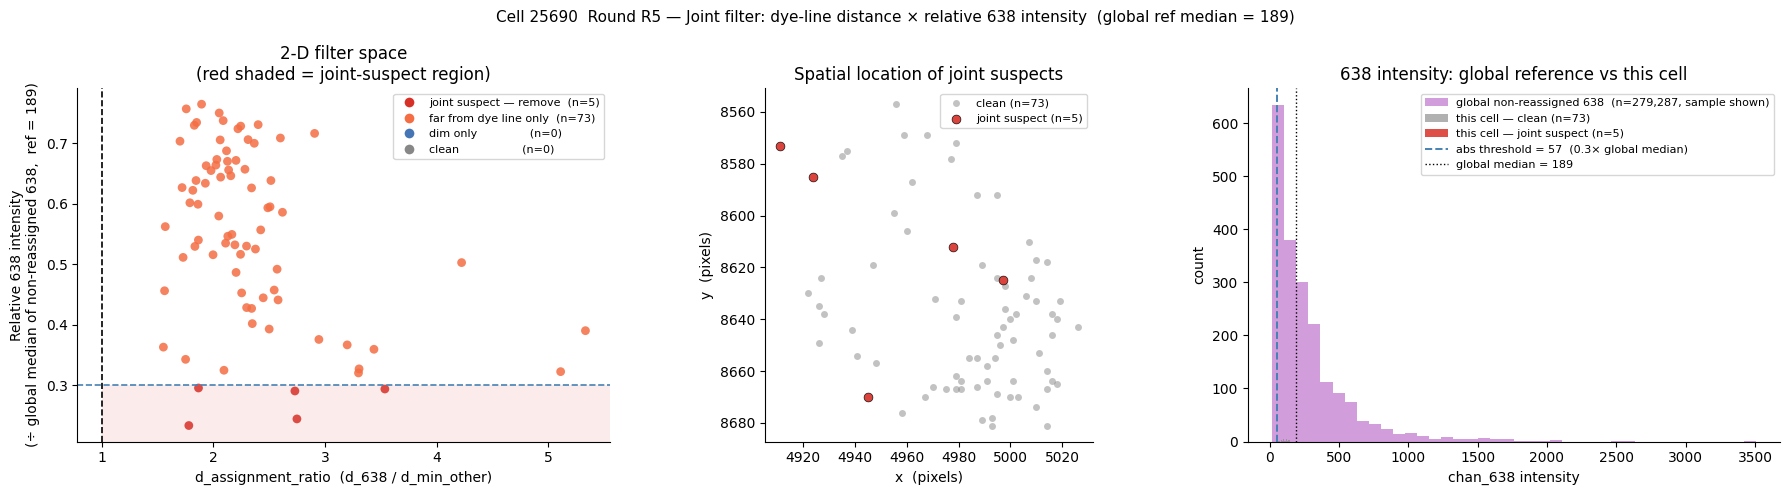

In [38]:

# ── Joint filter: dye-line distance × relative 638 intensity ──────────────────
# Tunable thresholds — adjust based on the violin/scatter diagnostics above
DIST_RATIO_THRESH = 1.0   # d_assignment_ratio > this → far from 638 dye line
REL_INT_THRESH    = 0.3   # relative intensity  < this → dim vs global true 638

# ── Global 638 reference: across ALL cells in the same round ──────────────────
# Use spots that were never reassigned (originally detected in 638, still
# assigned to 638 after unmixing). This population represents unambiguous
# HCR 638 signal from cells with strong expression — a much more robust
# reference than the within-cell median, which is biased when a cell has
# few or mostly suspect spots.
global_true_638 = unmixed_all[
    (unmixed_all["round"]        == QC_ROUND) &
    (unmixed_all["unmixed_chan"] == "638")    &
    (unmixed_all["chan"]         == "638")     # not reassigned from another channel
]["chan_638_intensity"]

ref_median = global_true_638.median()
ref_p25    = global_true_638.quantile(0.25)   # 25th pct for context

print(f"Global reference: {len(global_true_638):,} non-reassigned 638 spots "
      f"across all cells in {QC_ROUND}")
print(f"  median = {ref_median:.1f},  25th pct = {ref_p25:.1f}")

# Relative intensity: spot chan_638 intensity normalised to the global median
# → 1.0 = same brightness as a typical true 638 HCR spot anywhere in this round
u_638["rel_int_638"] = u_638["chan_638_intensity"] / ref_median

# Joint filter flags
u_638["far_from_dye_line"] = u_638["d_assignment_ratio"] > DIST_RATIO_THRESH
u_638["dim_relative_638"]  = u_638["rel_int_638"]         < REL_INT_THRESH
u_638["joint_suspect"]     = u_638["far_from_dye_line"]  & u_638["dim_relative_638"]

n_far  = u_638["far_from_dye_line"].sum()
n_dim  = u_638["dim_relative_638"].sum()
n_both = u_638["joint_suspect"].sum()
n_tot  = len(u_638)

print(f"\nCell {QC_CELL_ID}  Round {QC_ROUND} — 638-assigned spots: {n_tot}")
print(f"Far from dye line    (ratio > {DIST_RATIO_THRESH}):       {n_far} / {n_tot}")
print(f"Dim vs global 638    (rel < {REL_INT_THRESH}):            {n_dim} / {n_tot}")
print(f"JOINT suspect (both criteria):                            {n_both} / {n_tot}")

# ── visualise ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Cell {QC_CELL_ID}  Round {QC_ROUND} — "
    f"Joint filter: dye-line distance × relative 638 intensity  "
    f"(global ref median = {ref_median:.0f})",
    fontsize=11,
)

# ── Panel 0: 2-D filter space — ratio vs relative intensity ───────────────────
pt_colors = np.where(
    u_638["joint_suspect"],              "#d73027",   # both → red   (to remove)
    np.where(u_638["far_from_dye_line"], "#f46d43",   # far only → orange
    np.where(u_638["dim_relative_638"],  "#4575b4",   # dim only → blue
                                         "#878787"))  # neither  → grey
)
axes[0].scatter(
    u_638["d_assignment_ratio"], u_638["rel_int_638"],
    c=pt_colors, s=40, alpha=0.85, linewidths=0,
)
axes[0].axvline(DIST_RATIO_THRESH, color="black",     lw=1.2, ls="--",
                label=f"dist threshold = {DIST_RATIO_THRESH}")
axes[0].axhline(REL_INT_THRESH,    color="steelblue", lw=1.2, ls="--",
                label=f"intensity threshold = {REL_INT_THRESH}")

xlim, ylim = axes[0].get_xlim(), axes[0].get_ylim()
axes[0].add_patch(Rectangle(
    (DIST_RATIO_THRESH, ylim[0]),
    max(xlim[1], u_638["d_assignment_ratio"].max() * 1.1) - DIST_RATIO_THRESH,
    REL_INT_THRESH - ylim[0],
    facecolor="#d73027", alpha=0.09, zorder=0,
))

n_far_only = n_far - n_both
n_dim_only = n_dim - n_both
n_clean    = n_tot - n_far - n_dim + n_both
legend_elem = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#d73027', markersize=8,
           label=f'joint suspect — remove  (n={n_both})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#f46d43', markersize=8,
           label=f'far from dye line only  (n={n_far_only})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#4575b4', markersize=8,
           label=f'dim only               (n={n_dim_only})'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#878787', markersize=8,
           label=f'clean                  (n={n_clean})'),
]
axes[0].legend(handles=legend_elem, fontsize=8, framealpha=0.8)
axes[0].set_xlabel("d_assignment_ratio  (d_638 / d_min_other)")
axes[0].set_ylabel(
    f"Relative 638 intensity\n"
    f"(÷ global median of non-reassigned 638,  ref = {ref_median:.0f})"
)
axes[0].set_title("2-D filter space\n(red shaded = joint-suspect region)")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Panel 1: spatial — joint suspects highlighted ─────────────────────────────
clean_pts   = u_638[~u_638["joint_suspect"]]
suspect_pts = u_638[ u_638["joint_suspect"]]
axes[1].scatter(clean_pts["x"],   clean_pts["y"],
                c="#878787", s=25, alpha=0.5, linewidths=0,
                label=f"clean (n={len(clean_pts)})")
axes[1].scatter(suspect_pts["x"], suspect_pts["y"],
                c="#d73027", s=40, alpha=0.9,
                edgecolors="black", linewidths=0.5, zorder=5,
                label=f"joint suspect (n={len(suspect_pts)})")
axes[1].set_aspect("equal")
axes[1].invert_yaxis()
axes[1].set_xlabel("x  (pixels)")
axes[1].set_ylabel("y  (pixels)")
axes[1].set_title("Spatial location of joint suspects")
axes[1].legend(fontsize=8, framealpha=0.8)
axes[1].spines[["top", "right"]].set_visible(False)

# ── Panel 2: global reference distribution vs this cell ───────────────────────
# Downsample global distribution so the histogram isn't dominated by sheer numbers
sample_global = global_true_638.sample(min(len(global_true_638), 2000), random_state=42)
axes[2].hist(
    sample_global.values, bins=40, alpha=0.45,
    color=CHAN_COLORS.get("638", "#9C27B0"),
    label=f"global non-reassigned 638  (n={len(global_true_638):,}, sample shown)",
)
axes[2].hist(
    clean_pts["chan_638_intensity"].values, bins=25, alpha=0.65,
    color="#878787",
    label=f"this cell — clean (n={len(clean_pts)})",
)
if n_both > 0:
    axes[2].hist(
        suspect_pts["chan_638_intensity"].values, bins=15, alpha=0.85,
        color="#d73027",
        label=f"this cell — joint suspect (n={n_both})",
    )
int_abs_thresh = ref_median * REL_INT_THRESH
axes[2].axvline(int_abs_thresh, color="steelblue", lw=1.4, ls="--",
                label=f"abs threshold = {int_abs_thresh:.0f}  ({REL_INT_THRESH}× global median)")
axes[2].axvline(ref_median, color="black", lw=1.0, ls=":",
                label=f"global median = {ref_median:.0f}")
axes[2].set_xlabel("chan_638 intensity")
axes[2].set_ylabel("count")
axes[2].set_title("638 intensity: global reference vs this cell")
axes[2].legend(fontsize=8, framealpha=0.8)
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


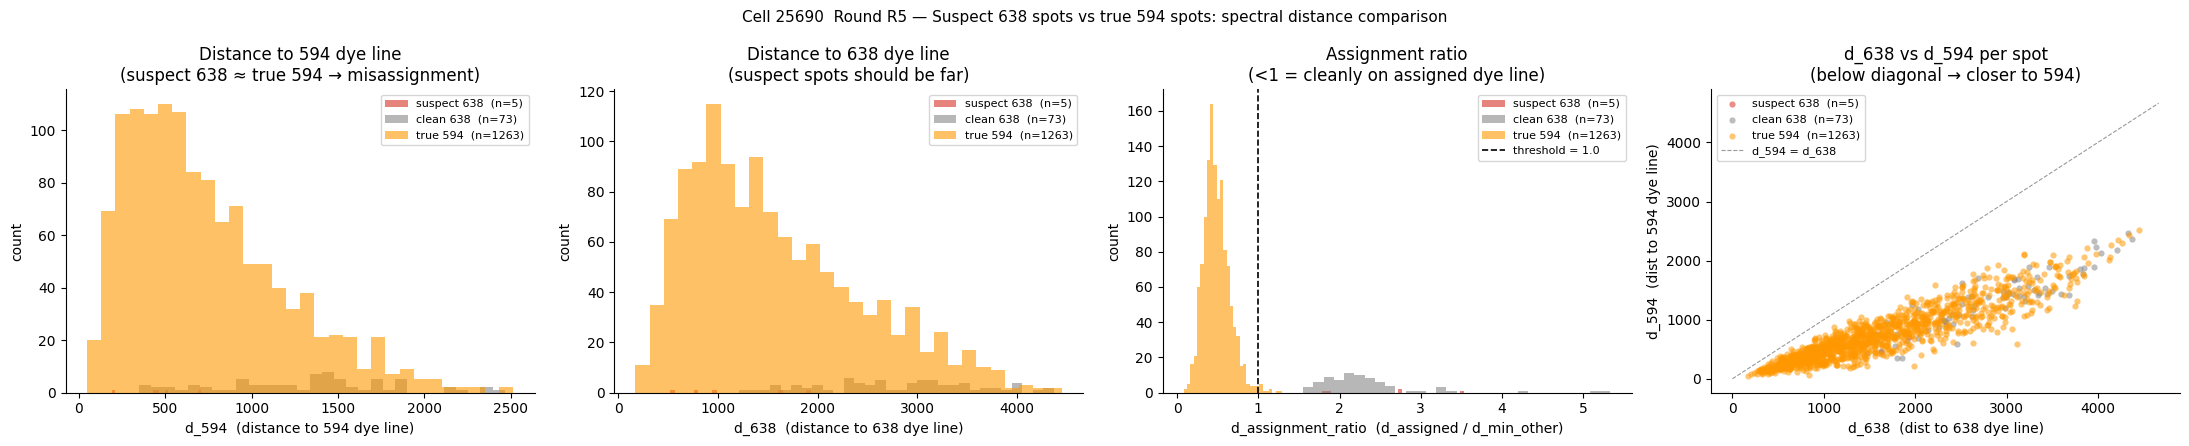

d_594 summary by group:
  suspect 638           median=461.1  mean=461.3  std=185.7  n=5
  clean 638             median=1387.3  mean=1309.6  std=504.2  n=73
  true 594              median=629.2  mean=730.9  std=447.6  n=1263

d_638 summary by group:
  suspect 638           median=949.6  mean=1163.2  std=595.6  n=5
  clean 638             median=2956.8  mean=2811.6  std=779.3  n=73
  true 594              median=1396.1  mean=1582.8  std=860.2  n=1263


In [39]:

# ── Compare suspect 638 spots vs true 594 spots: dye-line distance profile ────
# Compute dye-line distances for the 594-assigned spots in this cell so we can
# ask: do the suspect 638 spots look spectrally identical to real 594 spots?

u_594 = u_cell[u_cell["unmixed_chan"] == "594"].copy().reset_index(drop=True)
dist_594 = compute_dye_line_distances_numpy(u_594, ratios_df, chan_order=CHAN_ORDER)
u_594 = pd.concat([u_594, dist_594], axis=1)

# For 594 spots: d_assignment_ratio = d_594 / min(d of all other dye lines)
other_d_cols_594 = [f"d_{ch}" for ch in CHAN_ORDER if ch != "594" and f"d_{ch}" in u_594.columns]
u_594["d_assignment_ratio"] = u_594["d_594"] / u_594[other_d_cols_594].min(axis=1).replace(0, np.nan)

# Groups to compare across all panels:
#   A) suspect 638 spots  (far from 638 dye line AND dim vs global ref)
#   B) clean   638 spots  (not suspect)
#   C) true    594 spots  (assigned to 594 in this cell)
groups = {
    "suspect 638": (u_638[u_638["joint_suspect"]],   "#d73027"),
    "clean 638":   (u_638[~u_638["joint_suspect"]],  "#878787"),
    "true 594":    (u_594,                            CHAN_COLORS.get("594", "#FF9800")),
}

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))
fig.suptitle(
    f"Cell {QC_CELL_ID}  Round {QC_ROUND} — "
    "Suspect 638 spots vs true 594 spots: spectral distance comparison",
    fontsize=11,
)

# ── Panel 0: d_594 distribution ───────────────────────────────────────────────
for label, (df, col) in groups.items():
    vals = df["d_594"].dropna().values
    axes[0].hist(vals, bins=30, alpha=0.6, color=col, label=f"{label}  (n={len(vals)})")
axes[0].set_xlabel("d_594  (distance to 594 dye line)")
axes[0].set_ylabel("count")
axes[0].set_title("Distance to 594 dye line\n(suspect 638 ≈ true 594 → misassignment)")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Panel 1: d_638 distribution ───────────────────────────────────────────────
for label, (df, col) in groups.items():
    vals = df["d_638"].dropna().values
    axes[1].hist(vals, bins=30, alpha=0.6, color=col, label=f"{label}  (n={len(vals)})")
axes[1].set_xlabel("d_638  (distance to 638 dye line)")
axes[1].set_ylabel("count")
axes[1].set_title("Distance to 638 dye line\n(suspect spots should be far)")
axes[1].legend(fontsize=8)
axes[1].spines[["top", "right"]].set_visible(False)

# ── Panel 2: d_assignment_ratio distribution ──────────────────────────────────
# For suspect/clean 638: d_638/d_min_other.  For true 594: d_594/d_min_other.
# Both measure "how cleanly does this spot sit on its assigned dye line?"
for label, (df, col) in groups.items():
    vals = df["d_assignment_ratio"].dropna().values
    axes[2].hist(vals, bins=30, alpha=0.6, color=col, label=f"{label}  (n={len(vals)})")
axes[2].axvline(1.0, color="black", lw=1.2, ls="--", label="threshold = 1.0")
axes[2].set_xlabel("d_assignment_ratio  (d_assigned / d_min_other)")
axes[2].set_ylabel("count")
axes[2].set_title("Assignment ratio\n(<1 = cleanly on assigned dye line)")
axes[2].legend(fontsize=8)
axes[2].spines[["top", "right"]].set_visible(False)

# ── Panel 3: scatter d_594 vs d_638 for all three groups ─────────────────────
for label, (df, col) in groups.items():
    axes[3].scatter(df["d_638"], df["d_594"], c=col, s=20, alpha=0.55,
                    linewidths=0, label=f"{label}  (n={len(df)})")
# diagonal = equidistant from both dye lines
lim = max(axes[3].get_xlim()[1], axes[3].get_ylim()[1])
axes[3].plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.4, label="d_594 = d_638")
axes[3].set_xlabel("d_638  (dist to 638 dye line)")
axes[3].set_ylabel("d_594  (dist to 594 dye line)")
axes[3].set_title("d_638 vs d_594 per spot\n(below diagonal → closer to 594)")
axes[3].legend(fontsize=8)
axes[3].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# Summary stats
print("d_594 summary by group:")
for label, (df, _) in groups.items():
    v = df["d_594"].dropna()
    print(f"  {label:20s}  median={v.median():.1f}  mean={v.mean():.1f}  std={v.std():.1f}  n={len(v)}")
print()
print("d_638 summary by group:")
for label, (df, _) in groups.items():
    v = df["d_638"].dropna()
    print(f"  {label:20s}  median={v.median():.1f}  mean={v.mean():.1f}  std={v.std():.1f}  n={len(v)}")


In [16]:

# ── d_assignment_ratio for all channels ───────────────────────────────────────
# For each channel present in u_cell, compute distances and the assignment ratio:
#   d_assigned / min(d of all OTHER dye lines)
# ratio < 1 → spot sits closest to its assigned dye line (correctly assigned)
# ratio > 1 → some other dye line is closer (potentially misassigned)

all_chan_ratios = {}

for ch in CHAN_ORDER:
    sub = u_cell[u_cell["unmixed_chan"] == ch].copy().reset_index(drop=True)
    if len(sub) == 0:
        continue
    d = compute_dye_line_distances_numpy(sub, ratios_df, chan_order=CHAN_ORDER)
    d_self  = d[f"d_{ch}"]
    others  = [f"d_{c}" for c in CHAN_ORDER if c != ch and f"d_{c}" in d.columns]
    d_other = d[others].min(axis=1).replace(0, np.nan)
    ratio   = d_self / d_other
    all_chan_ratios[ch] = ratio.values

# ── plot ──────────────────────────────────────────────────────────────────────
chans_in_plot = [c for c in CHAN_ORDER if c in all_chan_ratios]
n_ch = len(chans_in_plot)
rng  = np.random.default_rng(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Cell {QC_CELL_ID}  Round {QC_ROUND} — "
    "d_assignment_ratio per channel  (d_assigned / d_min_other)",
    fontsize=11,
)

# ── Panel 0: violin + strip ───────────────────────────────────────────────────
for xi, ch in enumerate(chans_in_plot):
    vals  = all_chan_ratios[ch]
    color = CHAN_COLORS.get(ch, "grey")
    n     = len(vals)

    if n >= 5:
        parts = axes[0].violinplot(vals, positions=[xi], widths=0.65,
                                   showmedians=True, showextrema=False)
        for pc in parts["bodies"]:
            pc.set_facecolor(color); pc.set_alpha(0.45); pc.set_edgecolor("none")
        parts["cmedians"].set_color("white"); parts["cmedians"].set_linewidth(2); parts["cmedians"].set_zorder(4)

    jitter = rng.uniform(-0.18, 0.18, size=n)
    axes[0].scatter(xi + jitter, vals, c=color, s=8, alpha=0.4, linewidths=0, zorder=3)

axes[0].axhline(1.0, color="black", lw=1.2, ls="--", label="threshold = 1.0")
axes[0].set_xticks(range(n_ch))
axes[0].set_xticklabels([f"Ch {c}" for c in chans_in_plot], fontsize=9)
axes[0].set_ylabel("d_assigned / d_min_other")
axes[0].set_title("Distribution per channel\n(below 1 = correctly assigned)")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Panel 1: histogram overlaid, one color per channel ───────────────────────
for ch in chans_in_plot:
    vals  = all_chan_ratios[ch]
    n     = len(vals)
    color = CHAN_COLORS.get(ch, "grey")
    pct_mis = 100 * (vals > 1).mean()
    axes[1].hist(vals, bins=40, alpha=0.45, color=color,
                 label=f"Ch {ch}  (n={n}, {pct_mis:.0f}% >1)")

axes[1].axvline(1.0, color="black", lw=1.2, ls="--", label="threshold = 1.0")
axes[1].set_xlabel("d_assignment_ratio  (d_assigned / d_min_other)")
axes[1].set_ylabel("count")
axes[1].set_title("Overlaid histograms\n(ratio > 1 = closer to another dye line)")
axes[1].legend(fontsize=8, framealpha=0.8)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

# ── summary stats ─────────────────────────────────────────────────────────────
print(f"{'Channel':>8}  {'n':>5}  {'median':>7}  {'% >1':>6}  {'max':>7}")
for ch in chans_in_plot:
    vals = all_chan_ratios[ch]
    print(f"{ch:>8}  {len(vals):>5}  {np.median(vals):>7.3f}  "
          f"{100*(vals>1).mean():>5.1f}%  {vals.max():>7.3f}")


NameError: name 'compute_dye_line_distances_numpy' is not defined

### Plot 2 — Cross-channel intensity profile heatmap

For spots grouped by their assigned channel, compute the mean intensity in *every* channel.

- **Ideal unmixing** → near-diagonal matrix: Ch 488 spots are bright only in the 488 column, etc.  
- **Bleedthrough** → off-diagonal signal (e.g. a spot assigned to 561 that is also bright in 514).

Shown side-by-side: left = before (grouped by `chan`), right = after (grouped by `unmixed_chan`). Diagonal enrichment should increase after unmixing.


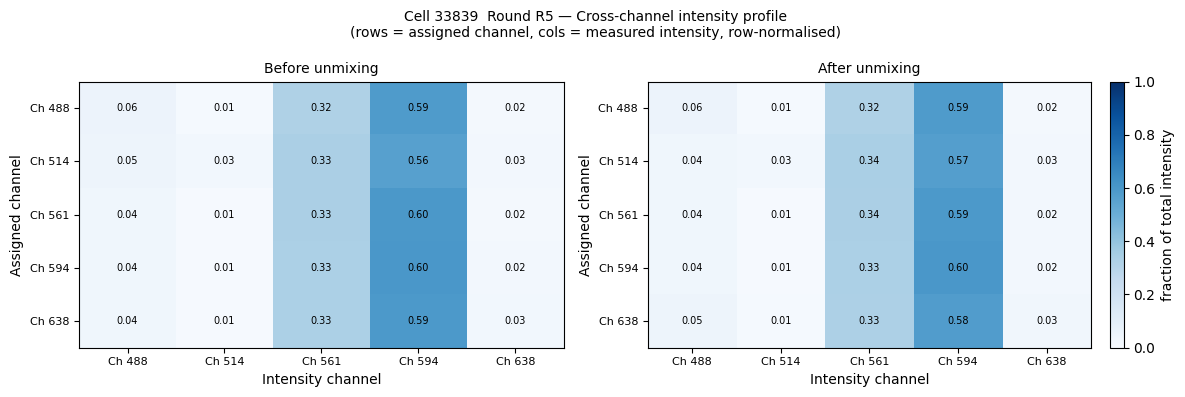

In [15]:
def _cross_channel_matrix(df, group_col):
    """Mean intensity of each chan_{N}_intensity column, grouped by group_col."""
    chans_present = [c for c in CHAN_ORDER if c in df[group_col].values]
    rows = {}
    for ch in chans_present:
        sub = df[df[group_col] == ch]
        rows[ch] = [sub[col].mean() for col in INTENSITY_COLS]
    mat = pd.DataFrame(rows, index=INTENSITY_CHANS).T   # rows = assigned channel, cols = intensity channel
    mat = mat.reindex(index=[c for c in CHAN_ORDER if c in mat.index],
                      columns=[c for c in CHAN_ORDER if c in mat.columns])
    # row-normalise so each row sums to 1 (fraction of signal in each channel)
    mat = mat.div(mat.sum(axis=1), axis=0)
    return mat

mat_before = _cross_channel_matrix(m_cell,  group_col="chan")
mat_after  = _cross_channel_matrix(u_cell,  group_col="unmixed_chan")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Cell {QC_CELL_ID}  Round {QC_ROUND} — Cross-channel intensity profile\n"
             "(rows = assigned channel, cols = measured intensity, row-normalised)",
             fontsize=10)

for ax, mat, title in [(axes[0], mat_before, "Before unmixing"),
                       (axes[1], mat_after,  "After unmixing")]:
    im = ax.imshow(mat.values, vmin=0, vmax=1, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels([f"Ch {c}" for c in mat.columns], fontsize=8)
    ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels([f"Ch {c}" for c in mat.index],   fontsize=8)
    ax.set_xlabel("Intensity channel"); ax.set_ylabel("Assigned channel")
    ax.set_title(title, fontsize=10)
    for i in range(len(mat.index)):
        for j in range(len(mat.columns)):
            v = mat.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if v > 0.6 else "black")

fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
             label="fraction of total intensity")
plt.tight_layout()
plt.show()


# Nearest Neighbors


## Reassignment matrix — all cells × all rounds

Count how many spots per cell changed channel after unmixing. Sorted by total reassignments so the most-affected cells float to the top — useful for picking cells to inspect further.


In [16]:
def compute_reassignment_matrix(unmixed_df):
    """
    Return a (cell_id × round) DataFrame counting how many spots were
    reassigned to a different channel after unmixing.

    The unmixed spots table already carries both `chan` (original) and
    `unmixed_chan` (assigned), so no merge with the mixed table is needed.

    Sorted descending by the row-sum (total reassignments across all rounds),
    so the most-affected cells appear first.
    """
    df = unmixed_df.copy()
    df["reassigned"] = df["chan"] != df["unmixed_chan"]

    counts = (
        df.groupby(["cell_id", "round"])["reassigned"]
        .sum()
        .astype(int)
        .reset_index(name="n_reassigned")
    )

    matrix = (
        counts.pivot(index="cell_id", columns="round", values="n_reassigned")
        .fillna(0)
        .astype(int)
    )

    # sort columns by round number (R1, R2, …)
    round_order = sorted(matrix.columns, key=lambda r: int(r.lstrip("R")))
    matrix = matrix[round_order]

    # sort rows by total reassignments descending
    matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]

    return matrix


reassignment_matrix = compute_reassignment_matrix(unmixed_all)
print(f"Shape: {reassignment_matrix.shape}  (cells × rounds)")
reassignment_matrix.head(20)


Shape: (25954, 5)  (cells × rounds)


round,R1,R2,R3,R4,R5
cell_id,,,,,
3,0,0,0,0,0
8,0,0,0,0,0
9,0,0,0,0,0
13,0,0,0,0,0
15,0,0,0,0,0
16,0,0,0,0,0
17,0,0,0,0,0
18,0,0,0,0,0
20,0,0,0,0,0


In [23]:
unmixed_all.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_561_intensity', 'chan_594_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'unmixed_gene', 'mixed_gene',
       'chan_514_intensity', 'chan_638_intensity'],
      dtype='str')

In [ ]:
reassignment_matrix

round
R1    0
R2    0
R3    0
R4    0
R5    0
dtype: int64

In [17]:
reassignment_matrix.tail(20)

round,R1,R2,R3,R4,R5
cell_id,,,,,
39080,0,0,0,0,0
39084,0,0,0,0,0
39090,0,0,0,0,0
39112,0,0,0,0,0
39125,0,0,0,0,0
39133,0,0,0,0,0
39134,0,0,0,0,0
39160,0,0,0,0,0
39208,0,0,0,0,0


## Removed matrix — all cells × all rounds

Spots present in the mixed table but absent from the unmixed table were filtered out (removed) during unmixing. Sorted by total removed across all rounds.


In [37]:
def compute_removed_matrix(mixed_df, unmixed_df):
    """
    Return a (cell_id × round) DataFrame counting how many spots were
    removed during unmixing (present in mixed table but absent from unmixed table).

    Sorted descending by the row-sum (total removed across all rounds),
    so the most-affected cells appear first.
    """
    survived_uids = set(unmixed_df["spot_uid"])
    df = mixed_df.copy()
    df["removed"] = ~df["spot_uid"].isin(survived_uids)

    counts = (
        df.groupby(["cell_id", "round"])["removed"]
        .sum()
        .astype(int)
        .reset_index(name="n_removed")
    )

    matrix = (
        counts.pivot(index="cell_id", columns="round", values="n_removed")
        .fillna(0)
        .astype(int)
    )

    # sort columns by round number (R1, R2, …)
    round_order = sorted(matrix.columns, key=lambda r: int(r.lstrip("R")))
    matrix = matrix[round_order]

    # sort rows by total removed descending
    matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index]

    return matrix


removed_matrix = compute_removed_matrix(mixed_all, unmixed_all)
print(f"Shape: {removed_matrix.shape}  (cells × rounds)")
removed_matrix.head(20)


Shape: (25954, 5)  (cells × rounds)


round,R1,R2,R3,R4,R5
cell_id,,,,,
33839,23,15,176,213,390
26838,14,16,118,119,308
29430,35,33,45,6,441
25690,0,0,0,16,512
32427,15,10,152,33,304
34946,22,6,8,178,292
25597,0,26,201,100,167
20066,4,18,66,68,325
34128,35,7,106,254,76


## Exemplar cell selection

Build a per-cell summary table with removal-rate per channel, then assign each cell to one of four categories:

| Category | Criterion |
|---|---|
| **clean** | global removal rate < 5 % |
| **pure_crosstalk** | any single channel removal rate ≥ 80 %, all others < 20 % |
| **mixed** | 1+ channels in 20–79 % removal range, not already pure |
| **high_global** | top 1 % by total removed spots |

Top 3 cells per category are returned as `exemplars`.


In [46]:
def build_cell_removal_summary(mixed_df, unmixed_df, chan_order=CHAN_ORDER, top_n=3):
    """
    Build a per-(cell_id, round) summary of removal rates per channel,
    assign category labels, and return:
      - summary_df  : full table, one row per (cell_id, round)
      - exemplars   : dict {category: DataFrame of top_n cells}

    Speedups vs naive loop version:
      - Only the 4 required columns are extracted (no full-df copy).
      - All aggregations are vectorised groupby ops (no Python loops).
      - Category assignment uses np.select instead of row-wise apply.
    """
    survived_uids = set(unmixed_df["spot_uid"])
    chans_in_data = [c for c in chan_order if c in mixed_df["chan"].values]

    # extract only what we need — avoids copying intensity columns
    df = mixed_df[["cell_id", "round", "chan", "spot_uid"]].copy()
    df["removed"] = ~df["spot_uid"].isin(survived_uids)

    # ── global counts per (cell_id, round) ──────────────────────────────────
    summary = (
        df.groupby(["cell_id", "round"])["removed"]
        .agg(n_total="count", n_removed="sum")
        .reset_index()
    )
    summary["n_removed"] = summary["n_removed"].astype(int)
    summary["removal_rate_global"] = summary["n_removed"] / summary["n_total"]

    # ── per-channel removal rate via pivot ───────────────────────────────────
    chan_agg = (
        df[df["chan"].isin(chans_in_data)]
        .groupby(["cell_id", "round", "chan"])["removed"]
        .agg(n_ch="count", n_removed_ch="sum")
        .reset_index()
    )
    chan_agg["rate"] = chan_agg["n_removed_ch"] / chan_agg["n_ch"]

    rate_pivot = chan_agg.pivot_table(
        index=["cell_id", "round"], columns="chan", values="rate"
    ).reset_index()
    rate_pivot.columns = (
        ["cell_id", "round"]
        + [f"removal_rate_{c}" for c in rate_pivot.columns[2:]]
    )

    count_pivot = chan_agg.pivot_table(
        index=["cell_id", "round"], columns="chan", values="n_ch"
    ).reset_index()
    count_pivot.columns = (
        ["cell_id", "round"]
        + [f"n_chan_{c}" for c in count_pivot.columns[2:]]
    )

    summary = summary.merge(rate_pivot,  on=["cell_id", "round"], how="left")
    summary = summary.merge(count_pivot, on=["cell_id", "round"], how="left")

    rate_cols = [f"removal_rate_{ch}" for ch in chans_in_data
                 if f"removal_rate_{ch}" in summary.columns]

    # ── vectorised category assignment ───────────────────────────────────────
    rates        = summary[rate_cols].to_numpy(dtype=float)   # (N, C)
    global_rate  = summary["removal_rate_global"].to_numpy()
    n_removed    = summary["n_removed"].to_numpy()
    top1_thresh  = np.nanquantile(n_removed, 0.99)

    max_rate            = np.nanmax(rates, axis=1)
    # NaN = channel absent → treat as "not bleedthrough", so counts toward below-20 tally
    n_below_20_or_nan   = np.sum((rates < 0.20) | np.isnan(rates), axis=1)
    n_chans             = rates.shape[1]

    pure_mask  = (max_rate >= 0.80) & (n_below_20_or_nan >= n_chans - 1)
    mixed_mask = np.any(rates >= 0.20, axis=1) & np.any(rates < 0.80, axis=1)

    # priority order: clean → high_global → pure_crosstalk → mixed → other
    summary["category"] = np.select(
        [global_rate < 0.05,
         n_removed >= top1_thresh,
         pure_mask,
         mixed_mask],
        ["clean", "high_global", "pure_crosstalk", "mixed"],
        default="other",
    )

    # ── top-N exemplars per category ─────────────────────────────────────────
    ex_cols   = ["cell_id", "round", "n_total", "n_removed",
                 "removal_rate_global"] + rate_cols + ["category"]
    exemplars = {}
    for cat in ["clean", "pure_crosstalk", "mixed", "high_global"]:
        sub = summary[summary["category"] == cat]
        sub = (sub.nsmallest(top_n, "removal_rate_global") if cat == "clean"
               else sub.nlargest(top_n, "n_removed"))
        exemplars[cat] = sub[ex_cols]

    return summary, exemplars


cell_summary, exemplars = build_cell_removal_summary(mixed_all, unmixed_all, top_n=3)

print(f"Total (cell, round) pairs: {len(cell_summary)}")
print("Category counts:\n", cell_summary["category"].value_counts().to_string())
print()
for cat, df in exemplars.items():
    print(f"── {cat} ──")
    print(df.to_string(index=False))
    print()


Total (cell, round) pairs: 124471
Category counts:
 category
clean             78839
mixed             40474
other              2111
pure_crosstalk     1791
high_global        1256

── clean ──
 cell_id round  n_total  n_removed  removal_rate_global  removal_rate_488  removal_rate_514  removal_rate_561  removal_rate_594  removal_rate_638 category
       3    R1        3          0                  0.0               NaN               NaN               0.0               NaN               NaN    clean
       3    R3        1          0                  0.0               0.0               NaN               NaN               NaN               NaN    clean
       3    R4        1          0                  0.0               0.0               NaN               NaN               NaN               NaN    clean

── pure_crosstalk ──
 cell_id round  n_total  n_removed  removal_rate_global  removal_rate_488  removal_rate_514  removal_rate_561  removal_rate_594  removal_rate_638       category
   

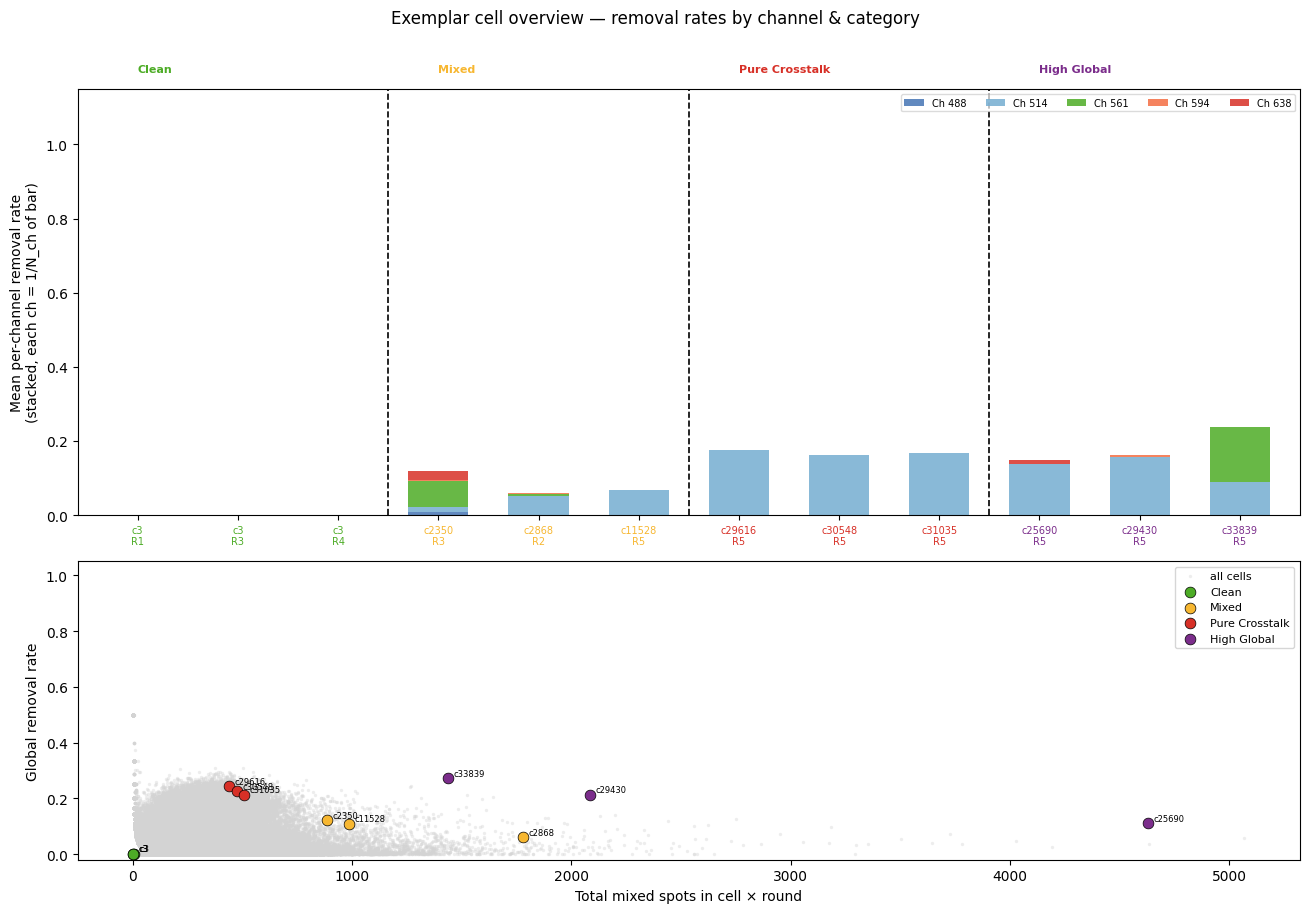

In [47]:
def plot_exemplar_overview(summary_df, exemplars, chan_order=CHAN_ORDER):
    """
    QC overview figure for exemplar cells.

    Top row   : stacked bar — per-channel removal rate for each exemplar,
                grouped by category (colour = channel, hatching = category).
    Bottom row: scatter — global removal rate vs total spots,
                all cells in grey, exemplars coloured by category.
    """
    CAT_ORDER  = ["clean", "mixed", "pure_crosstalk", "high_global"]
    CAT_COLORS = {"clean": "#4dac26", "mixed": "#f7b731",
                  "pure_crosstalk": "#d73027", "high_global": "#7b2d8b"}
    rate_cols  = [f"removal_rate_{ch}" for ch in chan_order
                  if f"removal_rate_{ch}" in summary_df.columns]
    chans      = [c.replace("removal_rate_", "") for c in rate_cols]
    CHAN_PALETTE = {"488": "#4575b4", "514": "#74add1", "561": "#4dac26",
                    "594": "#f46d43", "638": "#d73027"}

    # ── collect exemplar rows in category order ──────────────────────────────
    ex_rows = pd.concat(
        [exemplars[c] for c in CAT_ORDER if c in exemplars],
        ignore_index=True,
    )
    ex_rows["label"] = ex_rows.apply(
        lambda r: f"c{r.cell_id}\n{r['round']}", axis=1
    )

    n_ex = len(ex_rows)
    x    = np.arange(n_ex)
    bar_w = 0.6

    fig, (ax_bar, ax_sc) = plt.subplots(
        2, 1, figsize=(max(10, n_ex * 1.1), 9),
        gridspec_kw={"height_ratios": [2, 1.4]}
    )
    fig.suptitle("Exemplar cell overview — removal rates by channel & category",
                 fontsize=12, y=1.01)

    # ── stacked bar: per-channel removal rate ────────────────────────────────
    bottoms = np.zeros(n_ex)
    for ch, rc in zip(chans, rate_cols):
        vals = ex_rows[rc].fillna(0).values
        bars = ax_bar.bar(x, vals / len(chans),   # divide so stack sums to mean
                          bottom=bottoms, width=bar_w,
                          color=CHAN_PALETTE.get(ch, "grey"), alpha=0.85,
                          label=f"Ch {ch}")
        bottoms += vals / len(chans)

    # category boundary lines + labels
    prev_cat, seg_start = None, 0
    for idx, row in ex_rows.iterrows():
        cat = row["category"]
        if cat != prev_cat:
            if prev_cat is not None:
                ax_bar.axvline(idx - 0.5, color="black", lw=1.2, ls="--")
            ax_bar.text(idx, 1.04,
                        cat.replace("_", " ").title(),
                        transform=ax_bar.get_xaxis_transform(),
                        fontsize=8, color=CAT_COLORS[cat],
                        fontweight="bold")
            prev_cat = cat

    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(ex_rows["label"], fontsize=7)
    ax_bar.set_ylabel("Mean per-channel removal rate\n(stacked, each ch = 1/N_ch of bar)")
    ax_bar.set_ylim(0, 1.15)
    ax_bar.set_xlim(-0.6, n_ex - 0.4)
    ax_bar.legend(loc="upper right", fontsize=7, ncol=len(chans), framealpha=0.7)

    # colour the x-tick labels by category
    for tick, (_, row) in zip(ax_bar.get_xticklabels(), ex_rows.iterrows()):
        tick.set_color(CAT_COLORS[row["category"]])

    # ── scatter: total spots vs global removal rate ───────────────────────────
    ax_sc.scatter(summary_df["n_total"], summary_df["removal_rate_global"],
                  c="lightgrey", s=6, alpha=0.4, linewidths=0, zorder=1,
                  label="all cells")

    for cat in CAT_ORDER:
        sub = ex_rows[ex_rows["category"] == cat]
        ax_sc.scatter(sub["n_total"], sub["removal_rate_global"],
                      c=CAT_COLORS[cat], s=60, zorder=3,
                      edgecolors="black", linewidths=0.5,
                      label=cat.replace("_", " ").title())
        for _, r in sub.iterrows():
            ax_sc.annotate(f"c{r.cell_id}", (r.n_total, r.removal_rate_global),
                           fontsize=6, xytext=(4, 2), textcoords="offset points")

    ax_sc.set_xlabel("Total mixed spots in cell × round")
    ax_sc.set_ylabel("Global removal rate")
    ax_sc.legend(fontsize=8, loc="upper right", framealpha=0.8)
    ax_sc.set_ylim(-0.02, 1.05)

    plt.tight_layout()
    plt.show()


plot_exemplar_overview(cell_summary, exemplars)


## NN distance summary stats — pooled mice

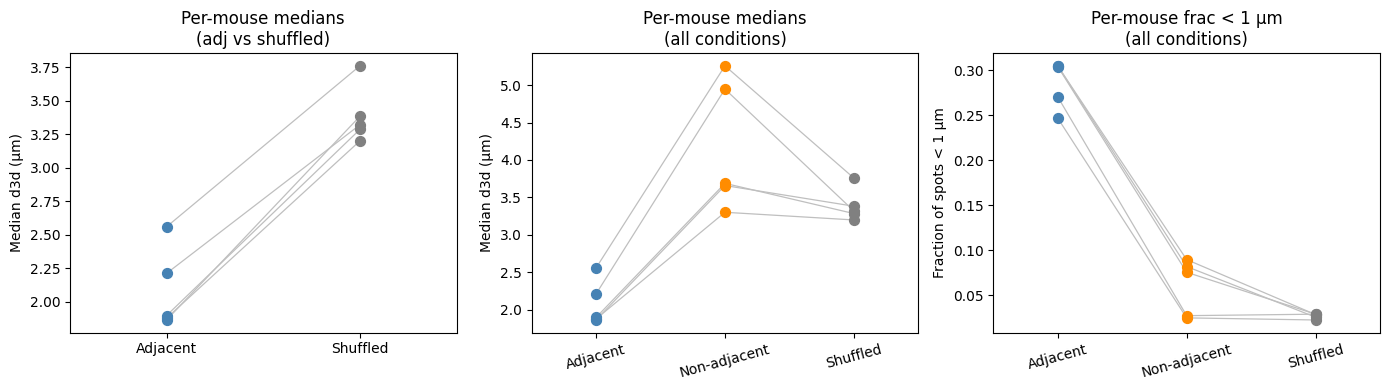

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

SUMMARY_PATH = "/root/capsule/scratch/single_cell_unmixing/pooled/nn_dist_summary.csv"
df = pd.read_csv(SUMMARY_PATH)

# ── per-mouse median (across all rounds & pairs) per condition ────────────────
per_mouse = (
    df[df["condition"].isin(["adjacent", "nonadjacent", "shuffled"])]
    .groupby(["mouse_id", "condition"])["median_d3d"]
    .median()
    .reset_index()
)

# ── per-condition pooled stats (median ± IQR) ─────────────────────────────────
pool_stats = (
    per_mouse.groupby("condition")["median_d3d"]
    .agg(["median", lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)])
    .rename(columns={"median": "med", "<lambda_0>": "q25", "<lambda_1>": "q75"})
)

cond_order  = ["adjacent", "nonadjacent", "shuffled"]
cond_labels = {"adjacent": "Adjacent", "nonadjacent": "Non-adjacent", "shuffled": "Shuffled"}
cond_colors = {"adjacent": "steelblue", "nonadjacent": "darkorange", "shuffled": "gray"}
x_pos       = {c: i for i, c in enumerate(cond_order)}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Panel 1: per-mouse strip + lines (adj vs shuffled) ────────────────────────
ax = axes[0]
strip_conds = ["adjacent", "shuffled"]
for mid, grp in per_mouse[per_mouse["condition"].isin(strip_conds)].groupby("mouse_id"):
    vals = {row["condition"]: row["median_d3d"] for _, row in grp.iterrows()}
    if "adjacent" in vals and "shuffled" in vals:
        ax.plot([0, 1], [vals["adjacent"], vals["shuffled"]],
                "o-", color="0.75", linewidth=0.9, markersize=4, zorder=2)
for i, cond in enumerate(strip_conds):
    vals = per_mouse.loc[per_mouse["condition"] == cond, "median_d3d"]
    ax.scatter([i] * len(vals), vals, color=cond_colors[cond], zorder=3, s=50)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Adjacent", "Shuffled"])
ax.set_ylabel("Median d3d (µm)")
ax.set_title("Per-mouse medians\n(adj vs shuffled)")
ax.set_xlim(-0.5, 1.5)

# ── Panel 2: strip across all three conditions ─────────────────────────────────
ax = axes[1]
for mid, grp in per_mouse.groupby("mouse_id"):
    xs = [x_pos[r["condition"]] for _, r in grp.iterrows() if r["condition"] in x_pos]
    ys = [r["median_d3d"]       for _, r in grp.iterrows() if r["condition"] in x_pos]
    ax.plot(xs, ys, "o-", color="0.75", linewidth=0.9, markersize=4, zorder=2)
for cond in cond_order:
    vals = per_mouse.loc[per_mouse["condition"] == cond, "median_d3d"]
    ax.scatter([x_pos[cond]] * len(vals), vals, color=cond_colors[cond], zorder=3, s=50,
               label=cond_labels[cond])
ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([cond_labels[c] for c in cond_order], rotation=15)
ax.set_ylabel("Median d3d (µm)")
ax.set_title("Per-mouse medians\n(all conditions)")
ax.set_xlim(-0.5, 2.5)

# ── Panel 3: frac_below_1um per condition ─────────────────────────────────────
ax = axes[2]
per_mouse_frac = (
    df[df["condition"].isin(cond_order)]
    .groupby(["mouse_id", "condition"])["frac_below_1um"]
    .median()
    .reset_index()
)
for mid, grp in per_mouse_frac.groupby("mouse_id"):
    xs = [x_pos[r["condition"]] for _, r in grp.iterrows() if r["condition"] in x_pos]
    ys = [r["frac_below_1um"]   for _, r in grp.iterrows() if r["condition"] in x_pos]
    ax.plot(xs, ys, "o-", color="0.75", linewidth=0.9, markersize=4, zorder=2)
for cond in cond_order:
    vals = per_mouse_frac.loc[per_mouse_frac["condition"] == cond, "frac_below_1um"]
    ax.scatter([x_pos[cond]] * len(vals), vals, color=cond_colors[cond], zorder=3, s=50)
ax.set_xticks(list(x_pos.values()))
ax.set_xticklabels([cond_labels[c] for c in cond_order], rotation=15)
ax.set_ylabel("Fraction of spots < 1 µm")
ax.set_title("Per-mouse frac < 1 µm\n(all conditions)")
ax.set_xlim(-0.5, 2.5)

fig.tight_layout()
plt.show()
